# Telco Customer Churn — Complete EDA & Data Cleaning
**Course:** STT 811 | **Semester:** Spring 2026

---

## STEP 1 — Install / Import Libraries

In [1]:
# Run this cell once if any library is missing
# !pip install pandas numpy matplotlib seaborn scipy openpyxl imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print('All libraries imported successfully!')

All libraries imported successfully!


---
## STEP 2 — Load Data

In [3]:
df_raw = pd.read_excel("C:/Users/brad_/OneDrive/Documents/MSU main/Year 1/Spring 26/STT 811- Stats/Project/Telco_customer_churn.xlsx")
df     = df_raw.copy()   # working copy — df_raw stays untouched

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 7,043 rows × 33 columns


---
## STEP 3 — First Look at the Data

In [4]:
# First 5 rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [5]:
# Last 5 rows
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.34,-116.54,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.67,-117.54,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.56,-115.64,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.17,-116.86,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.42,-117.18,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0,38,5097,NaN


In [6]:
# Column names, dtypes, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
# Descriptive statistics — numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Zip Code,7043.00,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Latitude,7043.00,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.00,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Tenure Months,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
Monthly Charges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
Churn Value,7043.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Churn Score,7043.00,58.70,21.53,5.00,40.00,61.00,75.00,100.00
CLTV,7043.00,4400.30,1183.06,2003.00,3469.00,4527.00,5380.50,6500.00


In [8]:
# Descriptive statistics — categorical columns
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3186-AJIEK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [9]:
# Unique values per column
unique_vals = pd.DataFrame({
    'dtype'       : df.dtypes,
    'unique_count': df.nunique(),
    'sample_values': [df[c].dropna().unique()[:4].tolist() for c in df.columns]
})
unique_vals

,dtype,unique_count,sample_values
CustomerID,object,7043,"[3668-QPYBK, 9237-HQITU, 9305-CDSKC, 7892-POOKP]"
Count,int64,1,[1]
Country,object,1,[United States]
State,object,1,[California]
City,object,1129,"[Los Angeles, Beverly Hills, Huntington Park, ..."
Zip Code,int64,1652,"[90003, 90005, 90006, 90010]"
Lat Long,object,1652,"[33.964131, -118.272783, 34.059281, -118.30742..."
Latitude,float64,1652,"[33.964131, 34.059281, 34.048013, 34.062125]"
Longitude,float64,1651,"[-118.272783, -118.30742, -118.293953, -118.31..."
Gender,object,2,"[Male, Female]"


---
## STEP 4 — Missing Values

In [10]:
# ── Raw missing counts ──────────────────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('=== Columns with Missing Values ===')
if missing_df.empty:
    print('  → No missing values detected in raw data.')
else:
    print(missing_df)

=== Columns with Missing Values ===
              Missing Count  Missing %
Churn Reason           5174      73.46


In [11]:
# ── Total Charges is stored as string — has blank spaces where tenure = 0 ──
print('Total Charges dtype (before fix):', df['Total Charges'].dtype)
print('/nSample blank/space values:')
print(df[df['Total Charges'].astype(str).str.strip() == ''][['CustomerID','Tenure Months','Monthly Charges','Total Charges']].head())

# Convert to float
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(f'\nNaN in Total Charges after conversion: {df["Total Charges"].isnull().sum()}')

Total Charges dtype (before fix): object
/nSample blank/space values:
      CustomerID  Tenure Months  Monthly Charges Total Charges
2234  4472-LVYGI              0            52.55              
2438  3115-CZMZD              0            20.25              
2568  5709-LVOEQ              0            80.85              
2667  4367-NUYAO              0            25.75              
2856  1371-DWPAZ              0            56.05              

NaN in Total Charges after conversion: 11


In [12]:
# Inspect those rows
df[df['Total Charges'].isnull()][
    ['CustomerID','Tenure Months','Monthly Charges','Total Charges','Churn Label']
]

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,NaN,No
2438,3115-CZMZD,0,20.25,NaN,No
2568,5709-LVOEQ,0,80.85,NaN,No
2667,4367-NUYAO,0,25.75,NaN,No
2856,1371-DWPAZ,0,56.05,NaN,No
4331,7644-OMVMY,0,19.85,NaN,No
4687,3213-VVOLG,0,25.35,NaN,No
5104,2520-SGTTA,0,20.00,NaN,No
5719,2923-ARZLG,0,19.70,NaN,No
6772,4075-WKNIU,0,73.35,NaN,No


In [13]:
# These are brand-new customers (tenure ~ 0) → fill with Monthly Charges
mask = df['Total Charges'].isnull()
df.loc[mask, 'Total Charges'] = df.loc[mask, 'Monthly Charges']
print(f'Remaining NaN in Total Charges: {df["Total Charges"].isnull().sum()}')

Remaining NaN in Total Charges: 0


---
## STEP 5 — Target Variable: Churn

In [14]:
churn_counts = df['Churn Label'].value_counts()
churn_pct    = df['Churn Label'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percent %': churn_pct.round(2)}))

=== Churn Distribution ===
             Count  Percent %
Churn Label                  
No            5174      73.46
Yes           1869      26.54


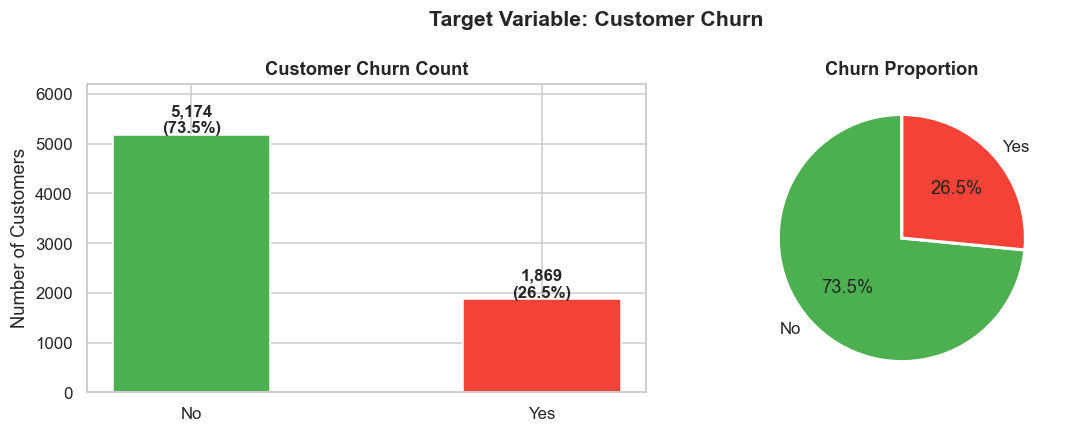

In [15]:
colors = ['#4CAF50', '#F44336']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=colors, edgecolor='white', width=0.45)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 40,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Customer Churn Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, max(churn_counts.values) * 1.2)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

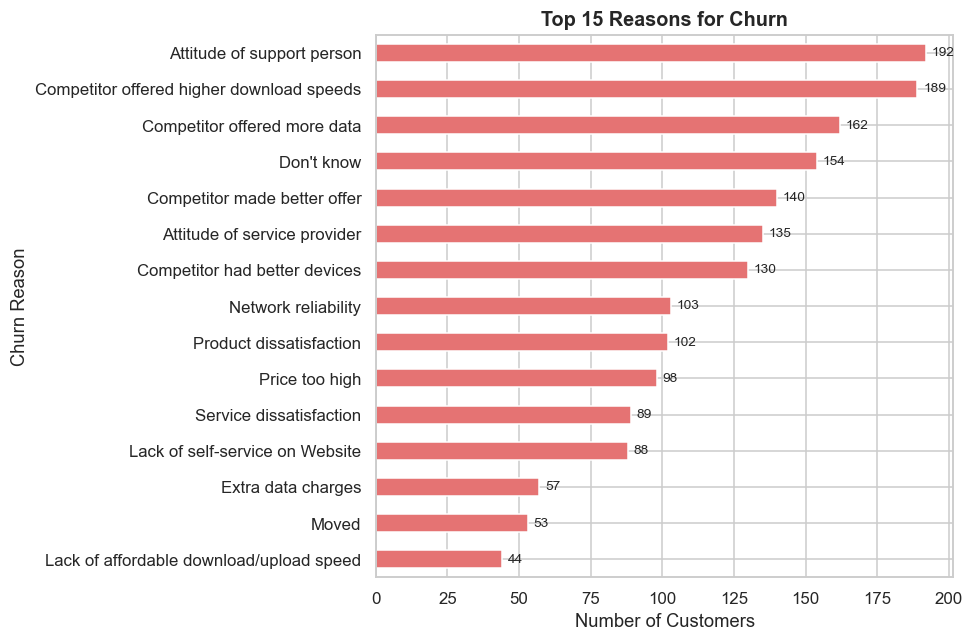

In [16]:
# Top churn reasons (churned customers only)
churn_reasons = (
    df[df['Churn Label'] == 'Yes']['Churn Reason']
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
churn_reasons.sort_values().plot(kind='barh', ax=ax,
                                  color='#E57373', edgecolor='white')
for i, val in enumerate(churn_reasons.sort_values().values):
    ax.text(val + 2, i, str(val), va='center', fontsize=9)
ax.set_title('Top 15 Reasons for Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.show()

---
## STEP 6 — Univariate Analysis: Numeric Features

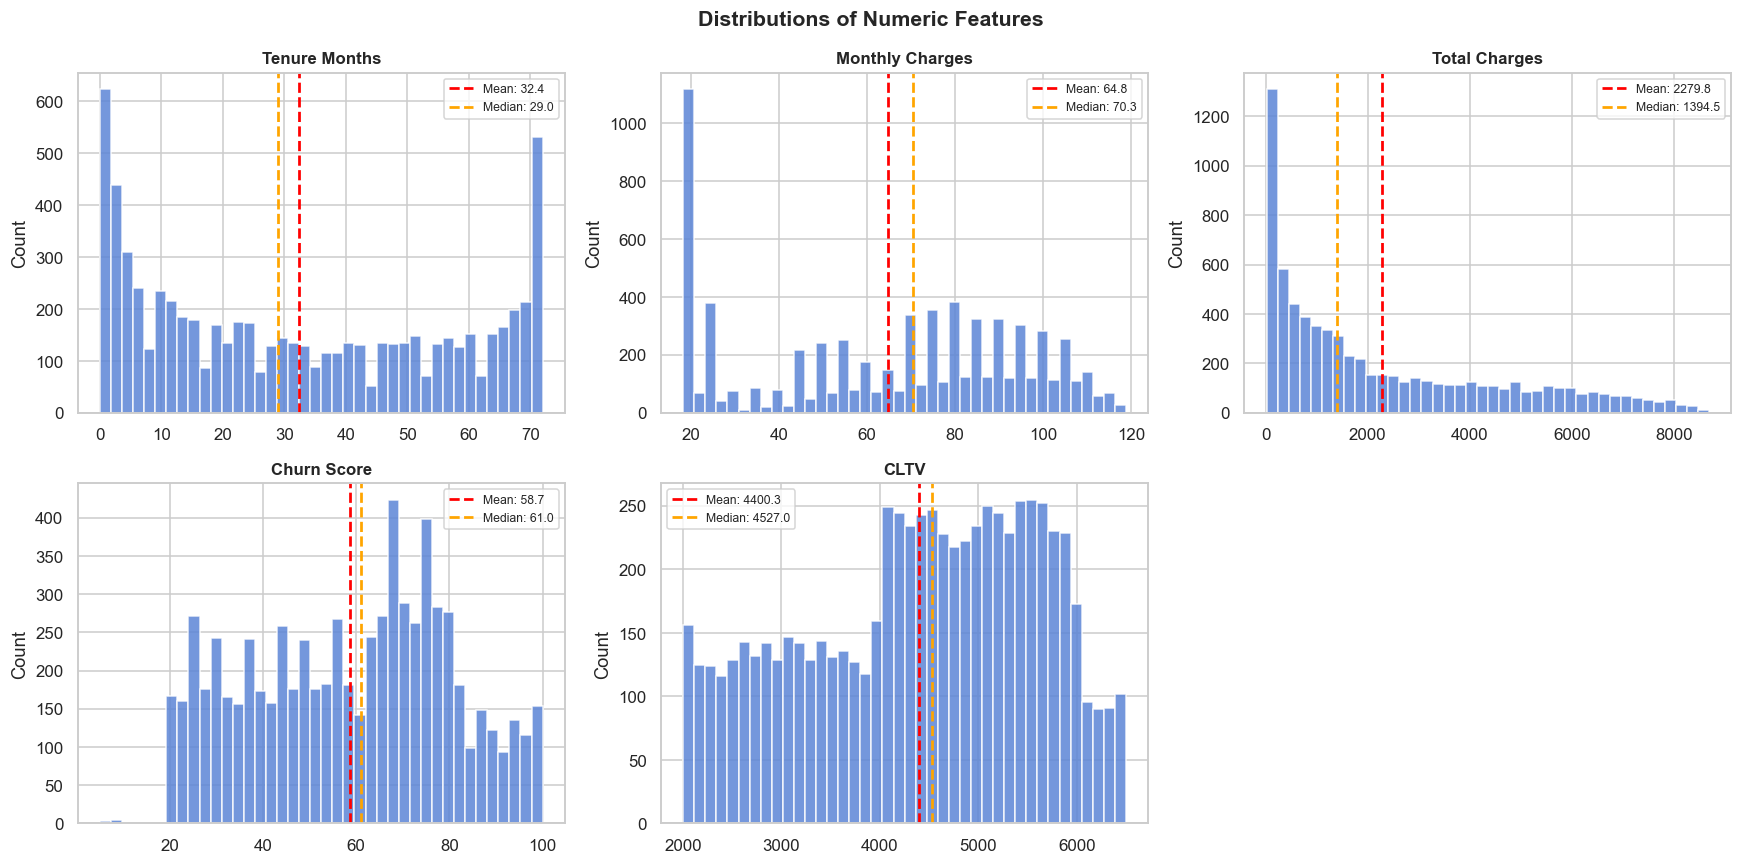

In [17]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#5C85D6', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', lw=1.8,
                    label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', lw=1.8,
                    label=f'Median: {data.median():.1f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distributions of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

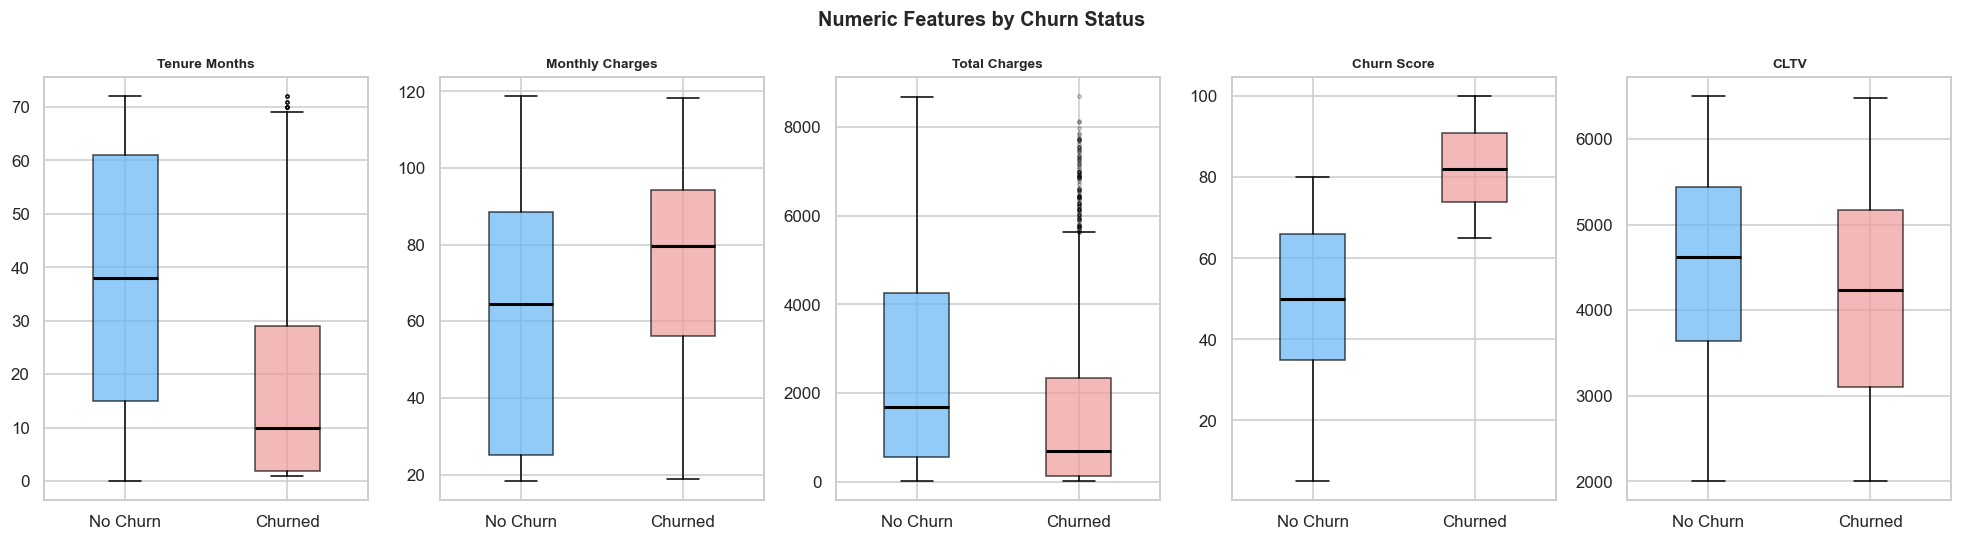

In [18]:
# Box plots — numeric features split by Churn
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    for label, color in zip(['No', 'Yes'], ['#64B5F6', '#EF9A9A']):
        subset = df[df['Churn Label'] == label][col].dropna()
        ax.boxplot(
            subset, positions=[0 if label == 'No' else 1],
            widths=0.4, patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray')
        )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Churn', 'Churned'])
    ax.set_title(col, fontsize=9, fontweight='bold')

plt.suptitle('Numeric Features by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Skewness & Kurtosis summary
skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
}).round(3)
print('=== Skewness & Kurtosis ===')
print(skew_kurt)

=== Skewness & Kurtosis ===
                 Skewness  Kurtosis
Tenure Months        0.24     -1.39
Monthly Charges     -0.22     -1.26
Total Charges        0.96     -0.23
Churn Score         -0.09     -1.01
CLTV                -0.31     -0.93


---
## STEP 7 — Univariate Analysis: Categorical Features

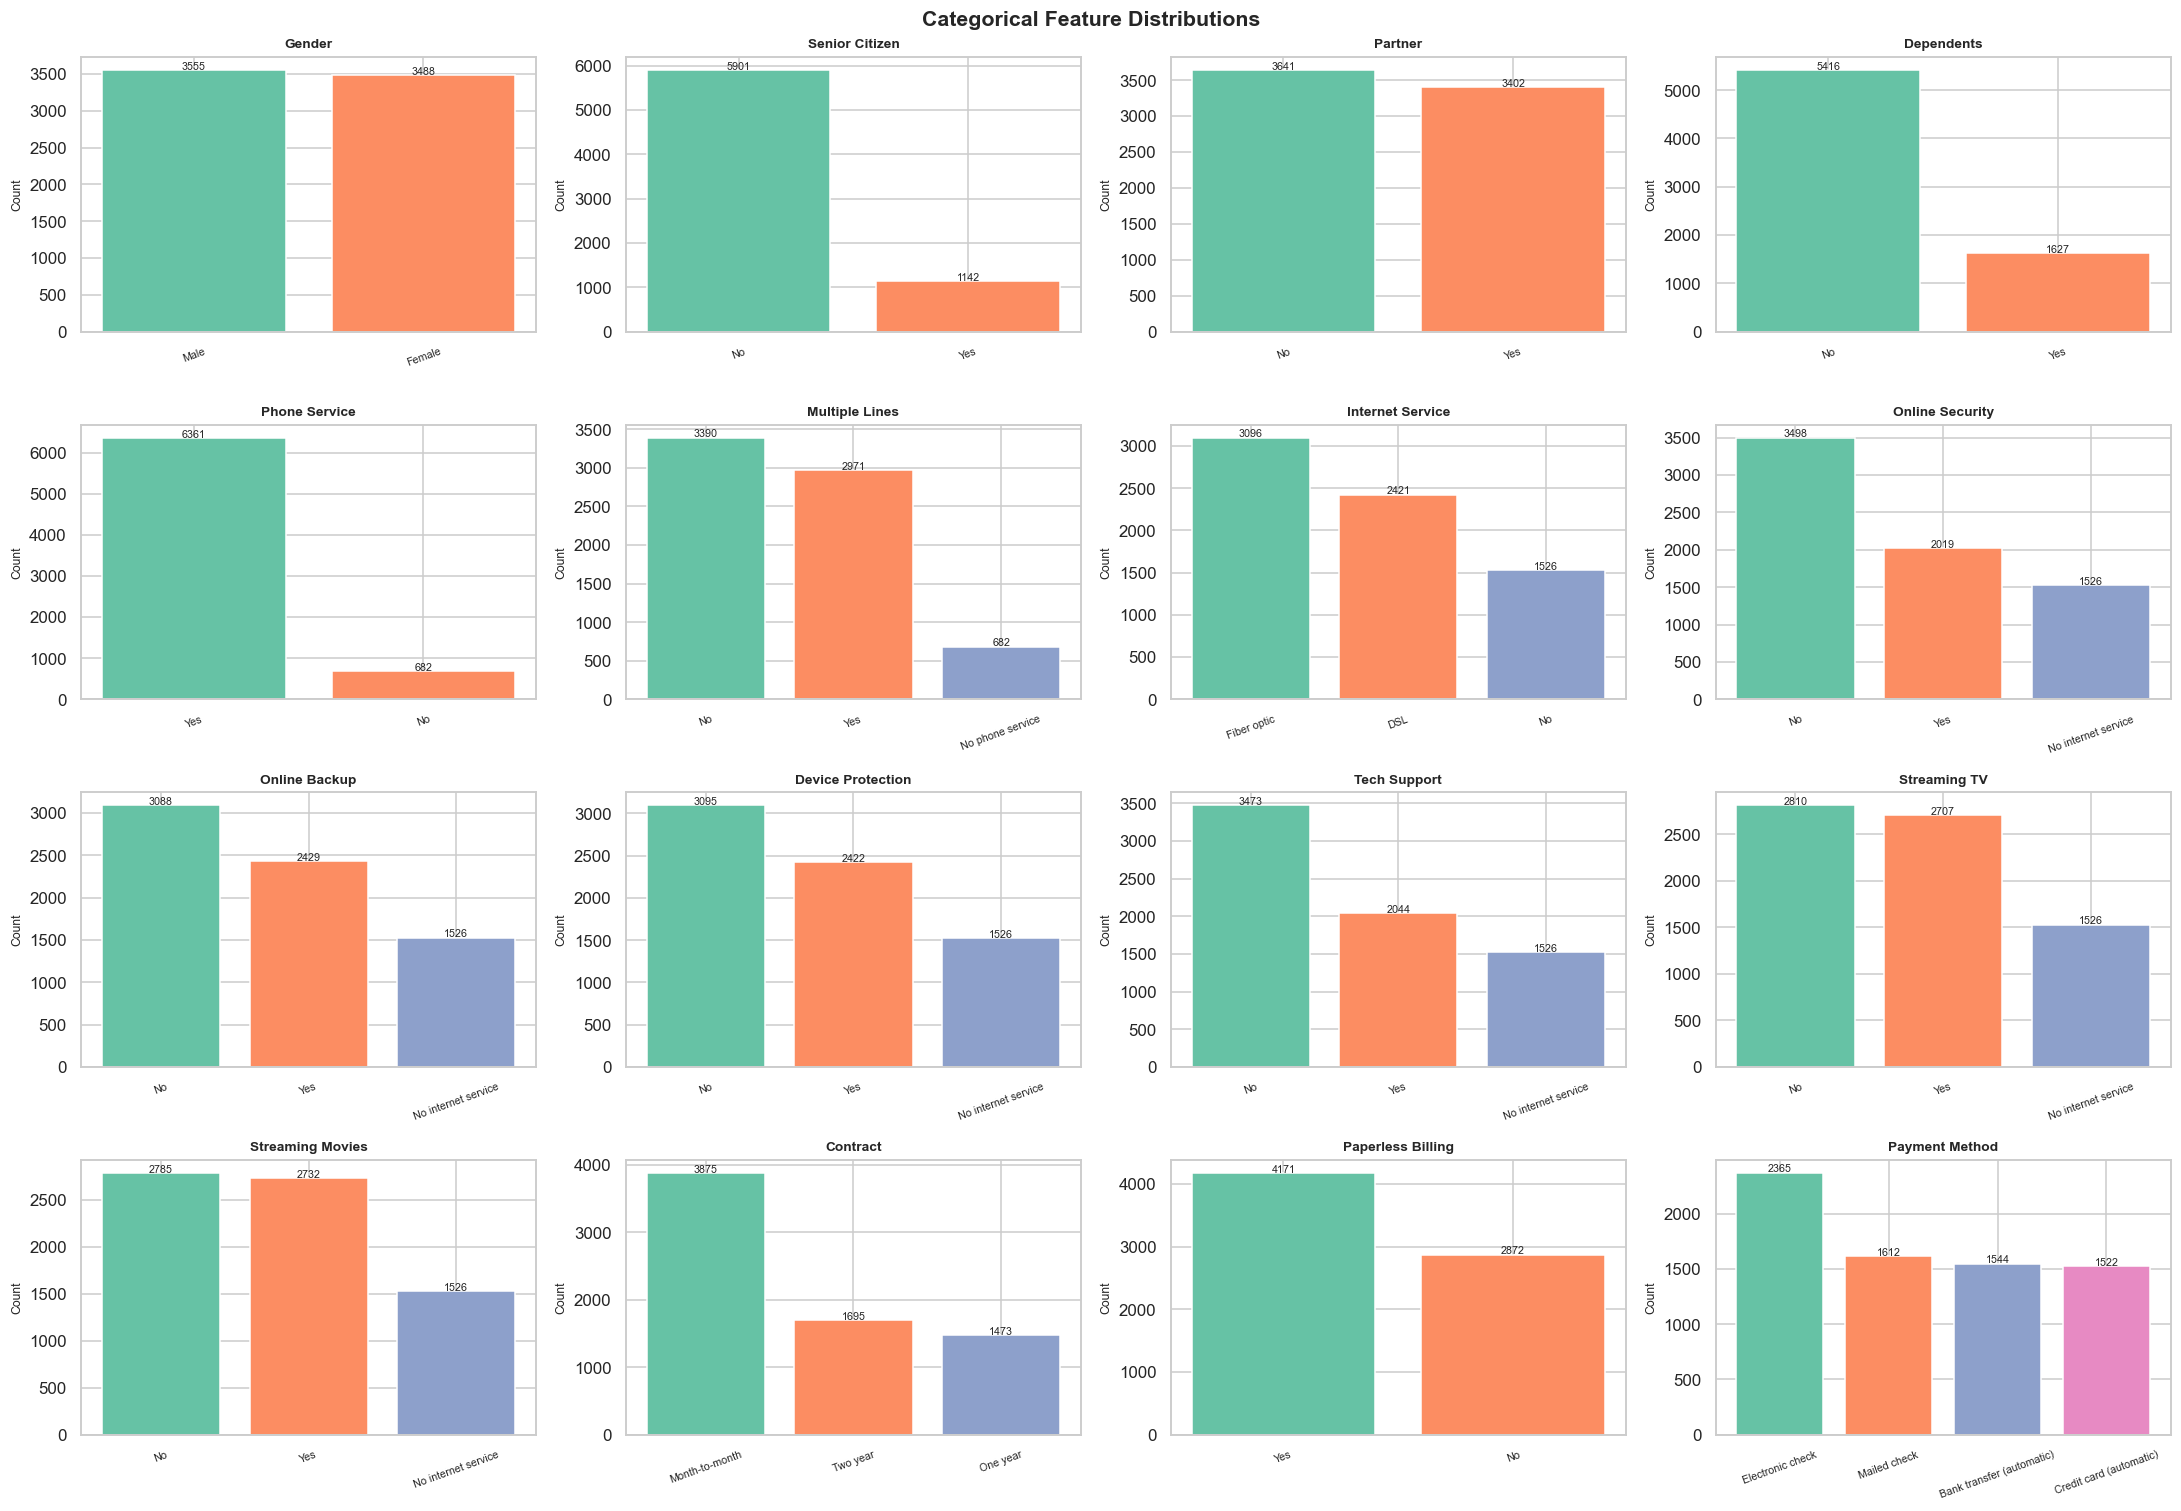

In [20]:
cat_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc     = df[col].value_counts()
    colors = sns.color_palette('Set2', len(vc))
    bars   = axes[i].bar(vc.index, vc.values, color=colors, edgecolor='white')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20, labelsize=7)
    axes[i].set_ylabel('Count', fontsize=8)
    for bar, v in zip(bars, vc.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 10,
                     str(v), ha='center', fontsize=7)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## STEP 8 — Bivariate Analysis: Features vs Churn

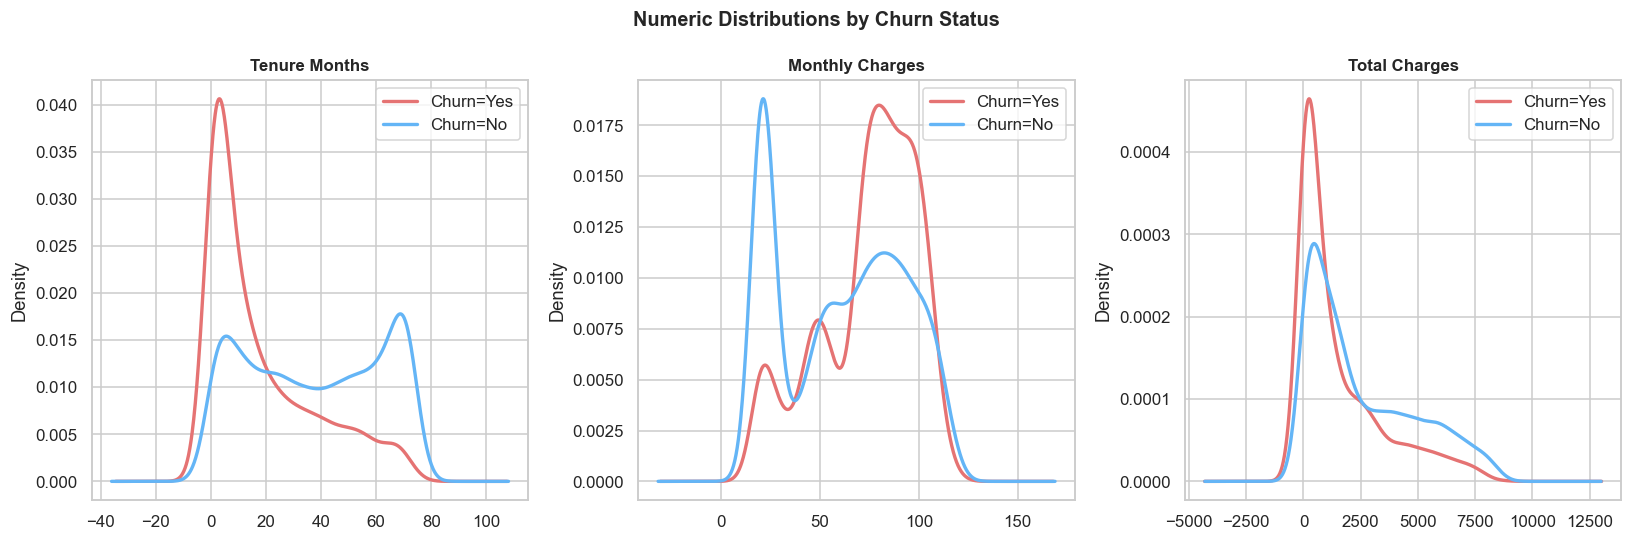

In [21]:
# KDE: numeric features split by Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Tenure Months', 'Monthly Charges', 'Total Charges']):
    for label, color in zip(['Yes', 'No'], ['#E57373', '#64B5F6']):
        df[df['Churn Label'] == label][col].dropna().plot.kde(
            ax=ax, label=f'Churn={label}', color=color, linewidth=2.2
        )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Numeric Distributions by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

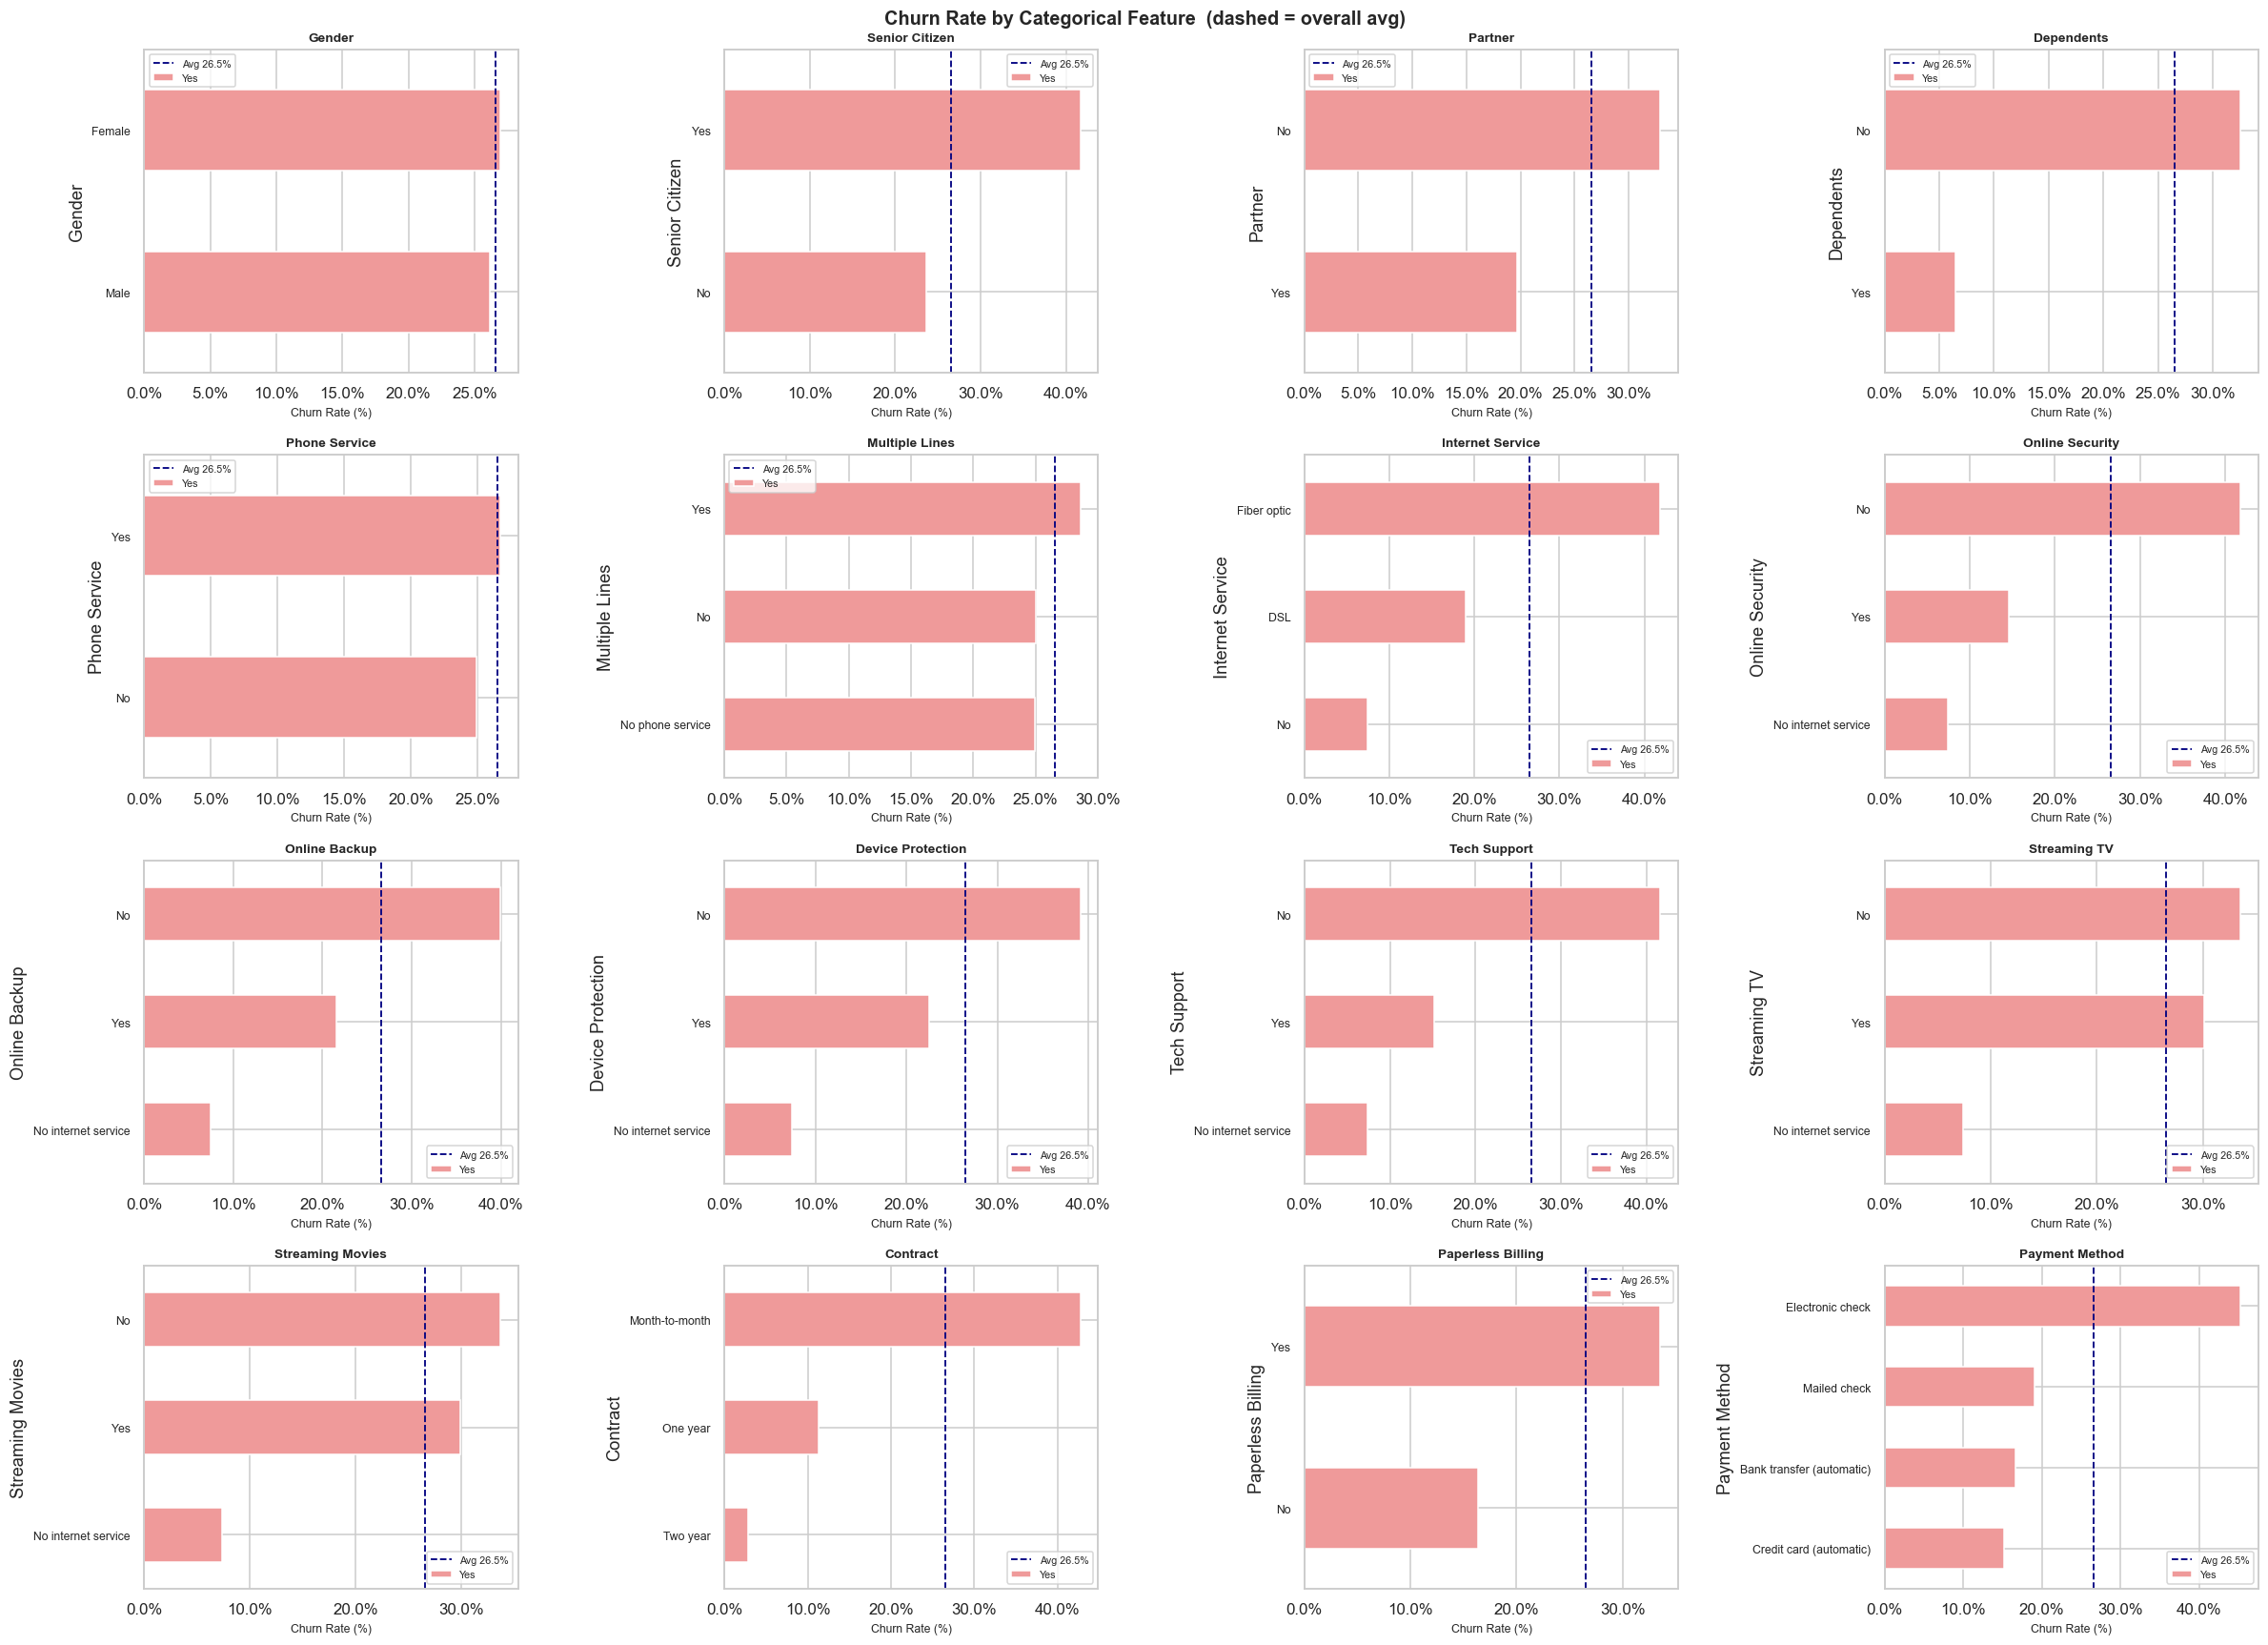

In [22]:
# Churn rate (%) for every categorical feature
overall_churn_rate = df['Churn Value'].mean() * 100

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    if 'Yes' in ct.columns:
        ct['Yes'].sort_values().plot(
            kind='barh', ax=axes[i], color='#EF9A9A', edgecolor='white'
        )
        axes[i].axvline(overall_churn_rate, color='navy',
                        linestyle='--', linewidth=1.2, label=f'Avg {overall_churn_rate:.1f}%')
        axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Churn Rate (%)', fontsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].xaxis.set_major_formatter(mtick.PercentFormatter())
        axes[i].legend(fontsize=7)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature  (dashed = overall avg)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

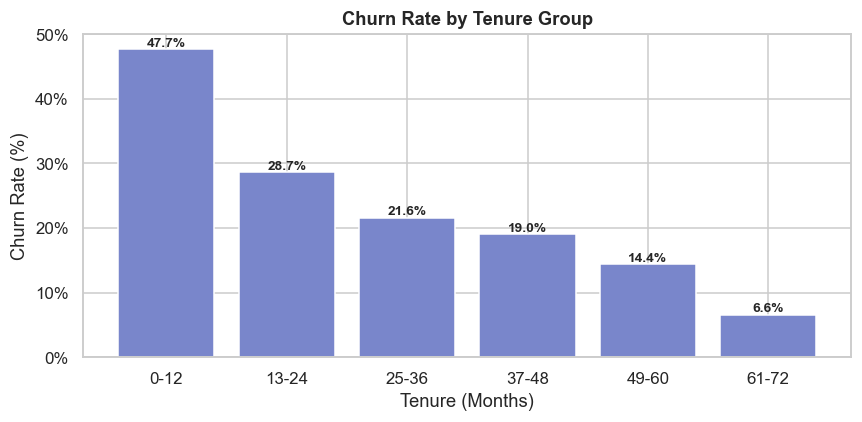

In [23]:
# Tenure groups vs Churn rate
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
)
tenure_churn = df.groupby('Tenure Group')['Churn Value'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tenure_churn.index, tenure_churn.values,
              color='#7986CB', edgecolor='white')
for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.4,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Churn Rate by Tenure Group', fontsize=12, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

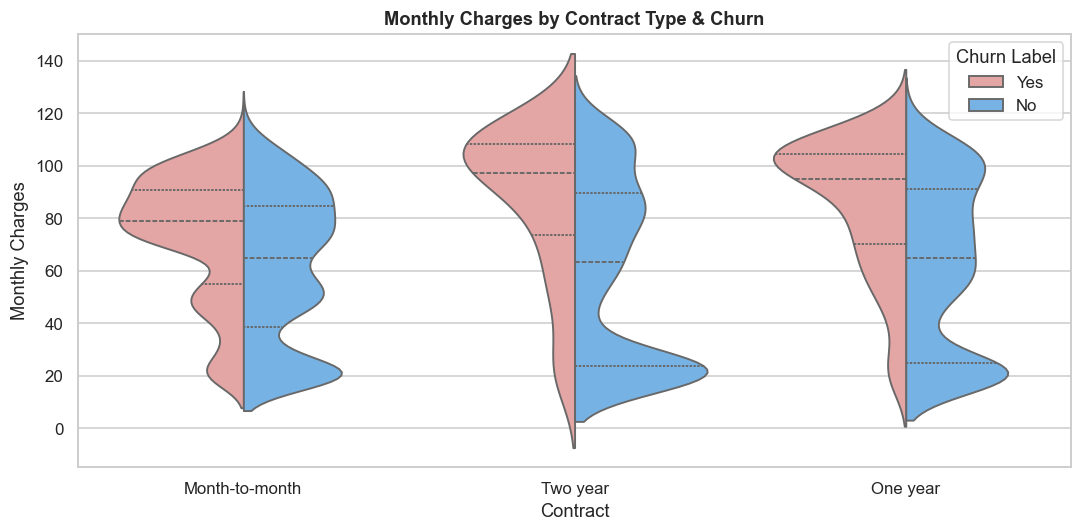

In [24]:
# Monthly charges vs Contract type (violin)
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df, x='Contract', y='Monthly Charges',
    hue='Churn Label', split=True, inner='quart',
    palette={'No': '#64B5F6', 'Yes': '#EF9A9A'}, ax=ax
)
ax.set_title('Monthly Charges by Contract Type & Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## STEP 9 — Correlation Analysis

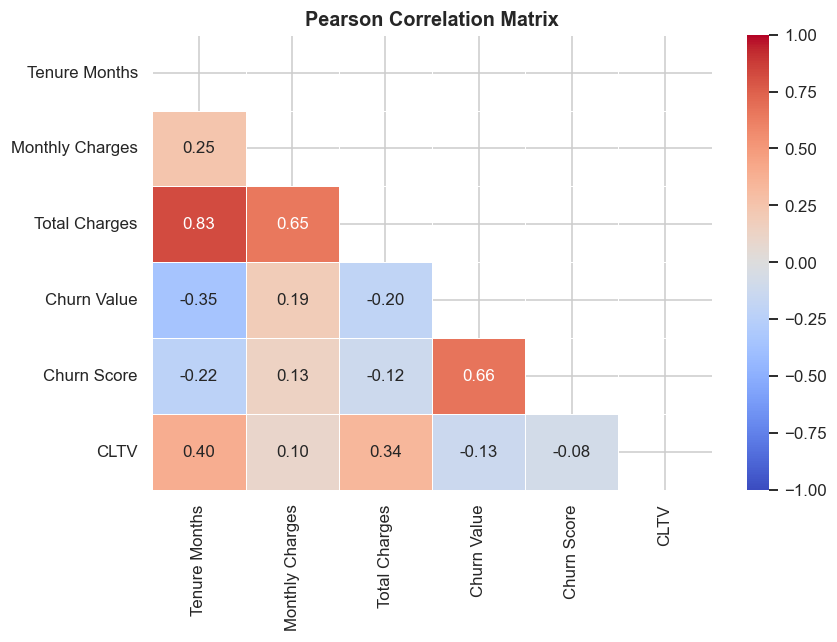

In [25]:
# Pearson correlation heatmap
corr_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges',
             'Churn Value', 'Churn Score', 'CLTV']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Point-biserial correlation with Churn Value
pb_results = {}
for col in ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']:
    clean = df[[col, 'Churn Value']].dropna()
    r, p  = pointbiserialr(clean['Churn Value'], clean[col])
    pb_results[col] = {'r': round(r, 4), 'p-value': round(p, 6),
                       'Significant': 'Yes' if p < 0.05 else 'No'}

pb_df = pd.DataFrame(pb_results).T.sort_values('r', key=abs, ascending=False)
print('=== Point-Biserial Correlation with Churn ===')
print(pb_df)

=== Point-Biserial Correlation with Churn ===
                    r p-value Significant
Churn Score      0.66    0.00         Yes
Tenure Months   -0.35    0.00         Yes
Total Charges   -0.20    0.00         Yes
Monthly Charges  0.19    0.00         Yes
CLTV            -0.13    0.00         Yes


In [27]:
# Chi-square test: categorical features vs Churn
from scipy.stats import chi2_contingency

chi2_results = {}
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn Label'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results[col] = {
        'chi2'       : round(chi2, 2),
        'p-value'    : round(p, 6),
        'Significant': 'Yes ✓' if p < 0.05 else 'No'
    }

chi2_df = pd.DataFrame(chi2_results).T.sort_values('chi2', ascending=False)
print('=== Chi-Square Test: Categorical Features vs Churn ===')
print(chi2_df)

=== Chi-Square Test: Categorical Features vs Churn ===
                     chi2 p-value Significant
Contract          1184.60    0.00       Yes ✓
Online Security    850.00    0.00       Yes ✓
Tech Support       828.20    0.00       Yes ✓
Internet Service   732.31    0.00       Yes ✓
Payment Method     648.14    0.00       Yes ✓
Online Backup      601.81    0.00       Yes ✓
Device Protection  558.42    0.00       Yes ✓
Dependents         433.73    0.00       Yes ✓
Streaming Movies   375.66    0.00       Yes ✓
Streaming TV       374.20    0.00       Yes ✓
Paperless Billing  258.28    0.00       Yes ✓
Senior Citizen     159.43    0.00       Yes ✓
Partner            158.73    0.00       Yes ✓
Multiple Lines      11.33    0.00       Yes ✓
Phone Service        0.92    0.34          No
Gender               0.48    0.49          No


### EDA Summary

| # | Finding | Detail |
|---|---|---|
| 1 | **Overall churn rate** | ~26.5% of customers churned |
| 2 | **Contract type** | Month-to-month churn ~43%; 2-year churn ~3% |
| 3 | **Internet service** | Fiber optic churn ~42% vs DSL ~19% |
| 4 | **Tenure** | New customers (0–12 mo) churn ~50%; drops sharply with age |
| 5 | **Monthly charges** | Churned customers pay ~\$20/mo more on average |
| 6 | **Add-on services** | No Online Security / Tech Support → much higher churn |
| 7 | **Payment method** | Electronic check users churn most (~45%) |
| 8 | **Top churn reasons** | Competitor offers (better devices, price, speed) |

---
## STEP 10 — Data Cleaning

In [28]:
# Start fresh from raw
df_clean = df_raw.copy()

# ── 10a. Fix Total Charges ──────────────────────────────────────────────────
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
mask_tc = df_clean['Total Charges'].isnull()
df_clean.loc[mask_tc, 'Total Charges'] = df_clean.loc[mask_tc, 'Monthly Charges']
print(f'Total Charges NaN remaining: {df_clean["Total Charges"].isnull().sum()}')

Total Charges NaN remaining: 0


In [29]:
# ── 10c. Rename target column ───────────────────────────────────────────────
df_clean.rename(columns={'Churn Value': 'Churn'}, inplace=True)
print('Target column renamed to: Churn')

Target column renamed to: Churn


### Cleaning Steps Applied
| Step | Action |
|---|---|
| Fix dtype | `Total Charges` string → float; 11 NaN filled with `Monthly Charges` |
| Renamed Target | changed target name from `Churn Value` to `Churn` |

---
## STEP 11 — Feature Engineering

In [30]:
# Average monthly spend (Total Charges / Tenure)
df_clean['Avg Monthly Spend'] = (
    df_clean['Total Charges'] / df_clean['Tenure Months'].replace(0, 1)
).round(2)

In [31]:
# Tenure Group
df_clean['Tenure Group'] = pd.cut(
    df_clean['Tenure Months'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[1, 2, 3, 4, 5, 6],
    include_lowest=True
).astype(int)

In [32]:
# Bill Shock Ratio
# Ratio of current monthly charge to their historical average
# > 1 means their bill has gone up; < 1 means it has gone down
df_clean['Bill_Shock_Ratio'] = (
    df_clean['Monthly Charges'] / df_clean['Avg Monthly Spend']
).round(3)

In [33]:
# Service Complexity / "Stickiness" Score
# Count of total internet-based add-on services (count how many columns equal 'Yes')
services = ['Online Security', 'Online Backup', 'Device Protection', 
            'Tech Support', 'Streaming TV', 'Streaming Movies']
df_clean['Total_Addon_Services'] = (df_clean[services] == 'Yes').sum(axis=1)

In [34]:
# Vulnerability Flag (1 if both Security and Support are exactly 'No')
df_clean['High_Risk_Security_Profile'] = (
    (df_clean['Online Security'] == 'No') & 
    (df_clean['Tech Support'] == 'No')
).astype(int)

In [35]:
# Automated Payment Flag
# Create a binary feature: 1 for Auto-pay, 0 for Manual pay
auto_pay_methods = ['Bank transfer (automatic)', 'Credit card (automatic)']
df_clean['Is_Auto_Pay'] = df_clean['Payment Method'].isin(auto_pay_methods).astype(int)

In [36]:
# Cost Per Service
# Monthly charge divided by the number of add-on services (+1 for the base internet connection)
df_clean['Cost_Per_Service'] = (
    df_clean['Monthly Charges'] / (df_clean['Total_Addon_Services'] + 1)
).round(2)

In [37]:
# ── Drop columns not useful for modeling ───────────────────────────────
cols_to_drop = [
    'CustomerID',   # unique identifier — no predictive value
    'Count',        # constant = 1 for every row
    'Country',      # constant = United States
    'State',        # constant = California
    'City',         # too granular; use Zip Code or lat/lon instead if needed
    'Zip Code',     # high cardinality identifier
    'Lat Long',     # duplicate of Latitude + Longitude
    'Latitude',     # geographic — not used in this model
    'Longitude',    # geographic — not used in this model
    'Churn Label',  # string version of target (Churn Value)
    'Churn Score',  # post-hoc derived score → data leakage
    'CLTV',         # post-hoc derived score → data leakage
    'Churn Reason'  # only available after churn happens → data leakage
]

df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after dropping: {df_clean.shape}')

Shape after dropping: (7043, 27)


In [38]:
# ── Binary encode Yes/No columns ──────────────────────────────────────
binary_yes_no = [
    'Partner', 'Dependents', 'Phone Service', 'Paperless Billing'
]
for col in binary_yes_no:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Senior Citizen: already 'Yes'/'No' text in this version
df_clean['Senior Citizen'] = df_clean['Senior Citizen'].map({'Yes': 1, 'No': 0})

# Gender
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

print('Binary encoding complete.')
df_clean[binary_yes_no + ['Senior Citizen', 'Gender']].value_counts().head()

Binary encoding complete.


Partner  Dependents  Phone Service  Paperless Billing  Senior Citizen  Gender
0        0           1              1                  0               1         722
                                                                       0         718
                                    0                  0               1         554
                                                                       0         505
1        0           1              1                  0               0         456
Name: count, dtype: int64

In [39]:
# ── One-hot encode multi-category columns ──────────────────────────────
ohe_cols = [
    'Multiple Lines',    # No / Yes / No phone service
    'Internet Service',  # DSL / Fiber optic / No
    'Online Security',   # No / Yes / No internet service
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Contract',          # Month-to-month / One year / Two year
    'Payment Method'     # 4 categories
]

df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=False)

# Convert boolean columns created by get_dummies to int (0/1)
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f'Shape after one-hot encoding: {df_clean.shape}')

Shape after one-hot encoding: (7043, 48)


### Preprocessing & Feature Engineering Summary

| Step | Action |
|---|---|
| **1. Feature Engineering** | 8 new behavioral and financial features created to capture churn risk (details below) |
| **2. Drop Columns** | 13 leakage / constant / identifier columns removed to prevent overfitting and data leakage |
| **3. Binary Encode** | 6 Yes/No columns + Gender mapped to 0/1 |
| **4. One-Hot Encode** | 10 multi-category columns → dummy variables (applied last to preserve feature engineering logic) |

<br>

#### Engineered Features Detail & Rationale

* **`Avg Monthly Spend`** The historical average spend per month (`Total Charges` / `Tenure Months`). 
  * **Reason:** Provides a baseline of what the customer is used to paying over their lifetime, smoothing out promotional periods.
* **`Tenure Group`** Groups continuous tenure months into 6 ordinal bins (yearly increments).
  * **Reason:** Churn risk often drops non-linearly over time (e.g., a huge drop after year 1). Bins help models capture these specific lifecycle milestones better than raw continuous numbers.
* **`Bill_Shock_Ratio`** The ratio of the current `Monthly Charges` to the `Avg Monthly Spend`.
  * **Reason:** A ratio > 1 indicates the customer's bill has gone up compared to their historical average. Sudden price hikes ("bill shock") are primary triggers for cancellation.
* **`Total_Addon_Services`** A sum of all active internet-based add-on services.
  * **Reason:** Measures "stickiness." Customers with multiple services (security, streaming, backup) are deeply integrated into the ecosystem and face higher switching costs to move to a competitor.
* **`High_Risk_Security_Profile`** A binary flag (1/0) for customers who lack *both* Online Security and Tech Support.
  * **Reason:** EDA specifically revealed that customers without these two support features churn at a drastically higher rate. This isolates that exact vulnerable segment.
* **`Is_Auto_Pay`** A binary flag indicating if the customer uses an automatic payment method (Credit Card or Bank Transfer).
  * **Reason:** Customers who manually pay via check face a monthly psychological decision to hand over money. Auto-pay removes this friction, historically lowering churn risk.
* **`Cost_Per_Service`** Divides the monthly bill by the total active services (including the base internet).
  * **Reason:** Measures the customer's perceived "value." A customer paying 100 dollars for 5 services is likely getting a better deal per-item than someone paying 100 dollars for just 1 service, impacting their satisfaction.

---
## STEP 11 — Export Cleaned Dataset

In [40]:
# OUTPUT_PATH = 'data/Telco_churn_cleaned.csv'

# df_clean.to_csv(OUTPUT_PATH, index=False)
# print(f'Cleaned dataset saved to:')
# print(f'  {OUTPUT_PATH}')
# print(f'  Rows: {df_clean.shape[0]:,} | Columns: {df_clean.shape[1]}')

Brad start: 
Four different models:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. Cox Proportional Hazards
5. Naive model for comparison

In [41]:
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

#data prep
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

#balance technique 1: Random Over-Sampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)

#balance technique 2: Random Under-Sampling 
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

#balance technique 3: SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

#check the results
print(f"Original shape: {y.value_counts().to_dict()}")
print(f"undersample shape: {y_rus.value_counts().to_dict()}")

  File "C:\Users\brad_\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\brad_\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\brad_\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\brad_\anaconda3\Lib\subprocess.

Original shape: {0: 5174, 1: 1869}
undersample shape: {0: 1869, 1: 1869}


Undersample with Logistic regression is best, moving forward all balanced data will be from undersampling. 

In [42]:
#Logistic Regression:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#split data
X = X_rus
y = y_rus
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train/test
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print(classification_report(y_test, lr_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       379
           1       0.78      0.80      0.79       369

    accuracy                           0.79       748
   macro avg       0.79      0.79      0.79       748
weighted avg       0.79      0.79      0.79       748



In [43]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#check Feature Importance
importances = rf_model.feature_importances_
print("Top Feature Importance:", importances[0])

Top Feature Importance: 0.014789243098496762


In [44]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       379
           1       0.75      0.79      0.77       369

    accuracy                           0.76       748
   macro avg       0.76      0.76      0.76       748
weighted avg       0.76      0.76      0.76       748



In [45]:
#Naive model
from sklearn.metrics import classification_report, accuracy_score
from sklearn.dummy import DummyClassifier

naive_model = DummyClassifier(strategy="most_frequent")
naive_model.fit(X_train, y_train)

y_pred_naive = naive_model.predict(X_test)
print(classification_report(y_test, y_pred_naive, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       379
           1       0.49      1.00      0.66       369

    accuracy                           0.49       748
   macro avg       0.25      0.50      0.33       748
weighted avg       0.24      0.49      0.33       748



<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'Tenure Months'
                event col = 'Churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13378.11
         time fit was run = 2026-04-15 15:44:48 UTC

---
                                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                 
Gender                                   -0.04      0.96      0.04           -0.12            0.04                0.89                1.04
Senior Citizen                            0.01      1.01      0.05           -0.08            0.11                0.92                1.12
Partner                                  -0.18      0.83      0.04           -0.27           -0.10                0.77                0.90
Dependents                               -0.58      0.56      0.06           -0.70           -0.46                0.50                0.63
Phone Service                            -0.02      0.98      0.10           -0.22            0.18                0.80                1.20
Paperless Billing                         0.14      1.15      0.05            0.05            0.23                1.05                1.26
Monthly Charges                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Total Charges                            -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
Avg Monthly Spend                         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Tenure Group                             -0.44      0.64      0.02           -0.47           -0.41                0.62                0.67
Bill_Shock_Ratio                          0.09      1.10      0.41           -0.72            0.90                0.49                2.46
Total_Addon_Services                     -0.01      0.99      0.02           -0.05            0.02                0.95                1.02
High_Risk_Security_Profile                0.18      1.20      0.06            0.06            0.30                1.06                1.35
Is_Auto_Pay                              -0.19      0.83      0.06           -0.31           -0.07                0.73                0.93
Cost_Per_Service                          0.00      1.00      0.00            0.00            0.01                1.00                1.01
Multiple Lines_No                         0.08      1.08      0.06           -0.03            0.19                0.97                1.21
Multiple Lines_No phone service           0.02      1.02      0.10           -0.18            0.22                0.83                1.25
Multiple Lines_Yes                       -0.09      0.92      0.06           -0.20            0.03                0.82                1.03
Internet Service_DSL                     -0.16      0.85      0.06           -0.29           -0.04                0.75                0.96
Internet Service_Fiber optic              0.21      1.24      0.06            0.09            0.34                1.09                1.40
Internet Service_No                      -0.09      0.91      0.09           -0.26            0.08                0.77                1.08
Online Security_No                        0.17      1.18      0.06            0.05            0.29                1.05                1.34
Online Security_No internet service      -0.09      0.91      0.09           -0.26            0.08                0.77                1.08
Online Security_Yes                      -0.13      0.88      0.07           -0.26       

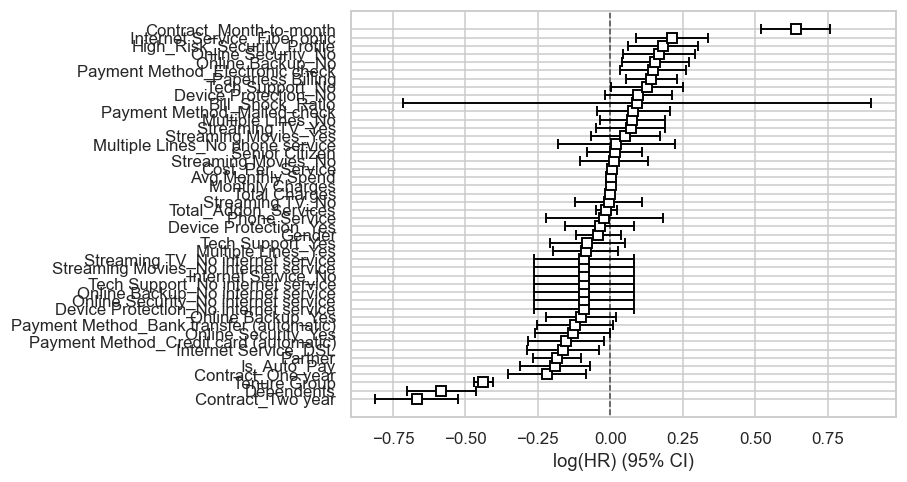

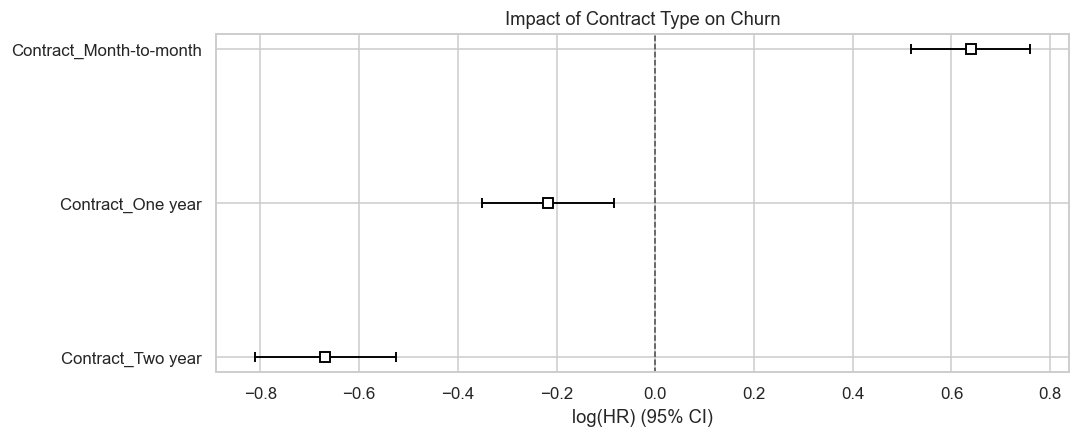

In [46]:
#Cox Proportional Hazards
#help from Gemini
from lifelines import CoxPHFitter
import pandas as pd

# 1. Handle Categorical Data (Essential for Cox)
# Using drop_first=True prevents the "singular matrix" error from redundant columns
df_cox = pd.get_dummies(df_clean, drop_first=True)

# 2. Initialize with a penalizer
# This "smoothes" the math and handles high correlation between features
cph = CoxPHFitter(penalizer=0.1) 

# 3. Fit using your specific column names
cph.fit(df_cox, duration_col='Tenure Months', event_col='Churn')

# 4. Display results
cph.print_summary()

# 5. Visualize the Hazard Ratios
# This shows which features push customers toward churn (right of 0) or away (left of 0)
cph.plot()

import matplotlib.pyplot as plt

# Example: Plotting only Contract-related features
contract_cols = [col for col in df_cox.columns if 'Contract' in col]

plt.figure(figsize=(10, 4))
cph.plot(columns=contract_cols)
plt.title("Impact of Contract Type on Churn")
plt.show()

Initial Model Comparison with Confussion Matrix, ROC curve and correlation heat map

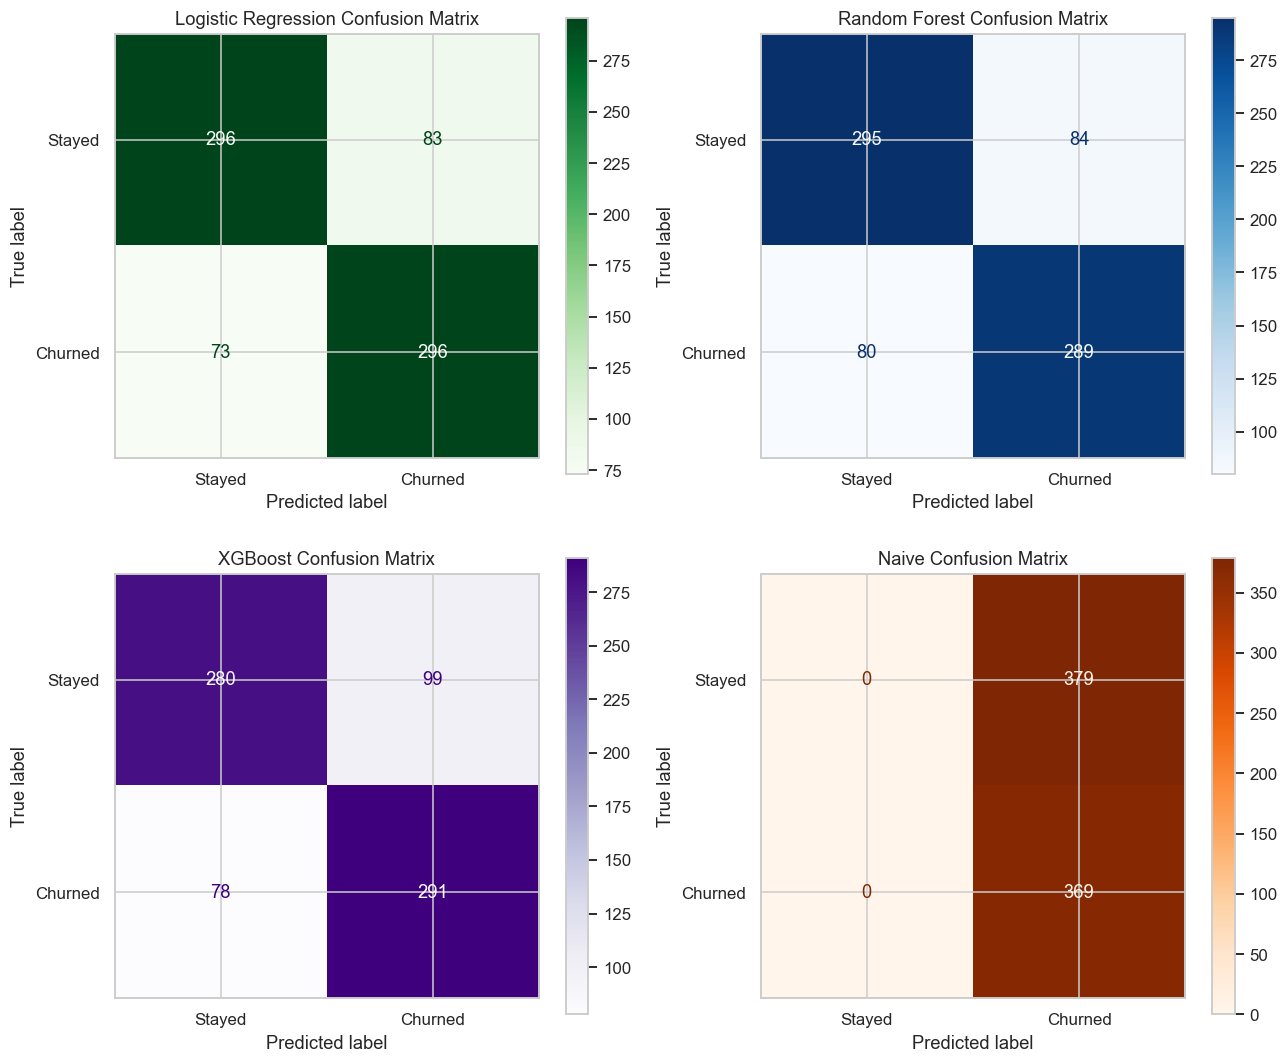

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#color mapping 
color_map_dict = {
    "Logistic Regression": plt.cm.Greens,
    "Random Forest": plt.cm.Blues,
    "XGBoost": plt.cm.Purples,
    "Naive": plt.cm.Oranges
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models_to_plot.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    current_cmap = color_map_dict.get(name, plt.cm.Reds) 
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=axes[i], cmap=current_cmap)
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

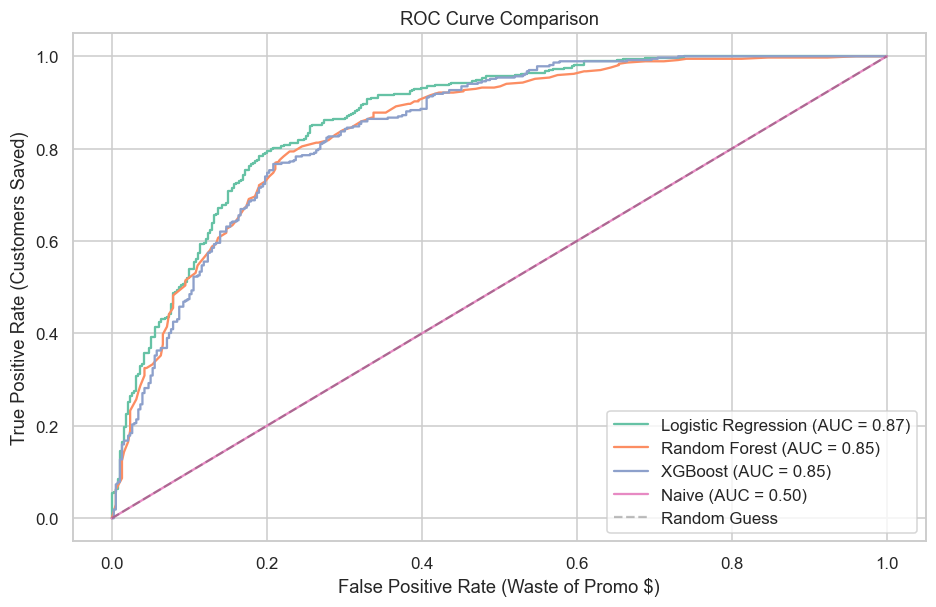

In [74]:
#ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

#get predicted probabilities 
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Naive': naive_model
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

#plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', alpha= 0.25)
plt.xlabel('False Positive Rate (Waste of Promo $)')
plt.ylabel('True Positive Rate (Customers Saved)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

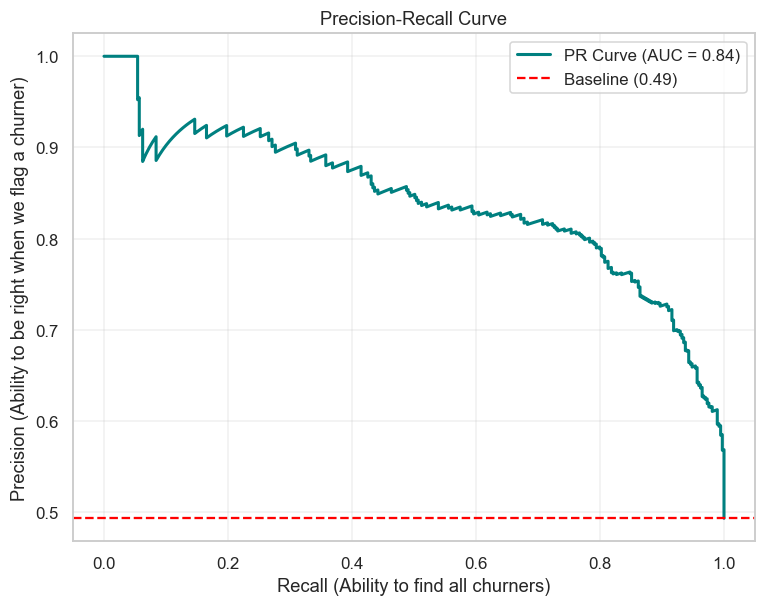

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

#get the probability scores for the positive class (churners)
y_scores = lr_model.predict_proba(X_test)[:, 1]

#calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

#calculate the Area Under the PR Curve (AUC-PR)
pr_auc = auc(recall, precision)

#plotting the Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='teal', lw=2)

#baseline churners in dataset
baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall (Ability to find all churners)')
plt.ylabel('Precision (Ability to be right when we flag a churner)')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

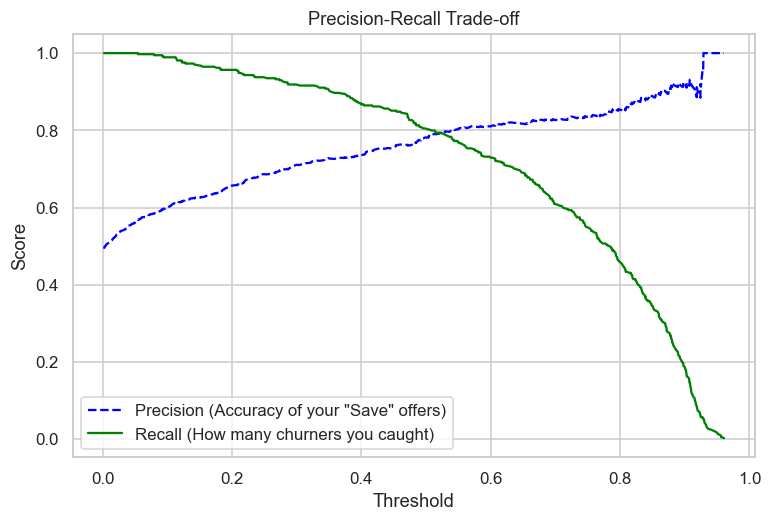

In [50]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

#get probabilities for churn
y_scores = lr_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision (Accuracy of your "Save" offers)')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall (How many churners you caught)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
import numpy as np
#gemini help
# Example Costs (Adjust these based on your business)
cost_of_churn = 100 
cost_of_retention_offer = 20

profits = []
threshold_range = np.linspace(0, 1, 100)

for t in threshold_range:
    preds = (y_scores >= t).astype(int)
    # True Positives: People we saved (Benefit = Churn Cost - Offer Cost)
    tp = np.sum((preds == 1) & (y_test == 1))
    # False Positives: People we gave a useless discount (Cost = Offer Cost)
    fp = np.sum((preds == 1) & (y_test == 0))
    
    total_profit = (tp * (cost_of_churn - cost_of_retention_offer)) - (fp * cost_of_retention_offer)
    profits.append(total_profit)

best_threshold = threshold_range[np.argmax(profits)]
print(f"The mathematically optimal threshold is: {best_threshold:.2f}")

The mathematically optimal threshold is: 0.11


In [52]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

#get raw probabilities
y_probs = lr_model.predict_proba(X_test)[:, 1]

#define the thresholds to test
thresholds = [0.15, 0.30, 0.50, 0.70]
results = []

for t in thresholds:
    #apply threshold
    y_pred_t = (y_probs >= t).astype(int)
    
    #calculate metrics
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    #how many people targeted for retention
    total_targeted = y_pred_t.sum()
    
    results.append({
        "Threshold": t,
        "Precision (Quality)": f"{(precision * 100):.1f}%",
        "Recall (Quantity)": f"{(recall * 100):.1f}%",
        "F1-Score": f"{f1:.2f}",
        "Customers Flagged": total_targeted
    })

#clean table
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Threshold Precision (Quality) Recall (Quantity) F1-Score  Customers Flagged
      0.15               62.5%             96.7%     0.76                571
      0.30               71.0%             91.6%     0.80                476
      0.50               78.1%             80.2%     0.79                379
      0.70               82.7%             60.7%     0.70                271


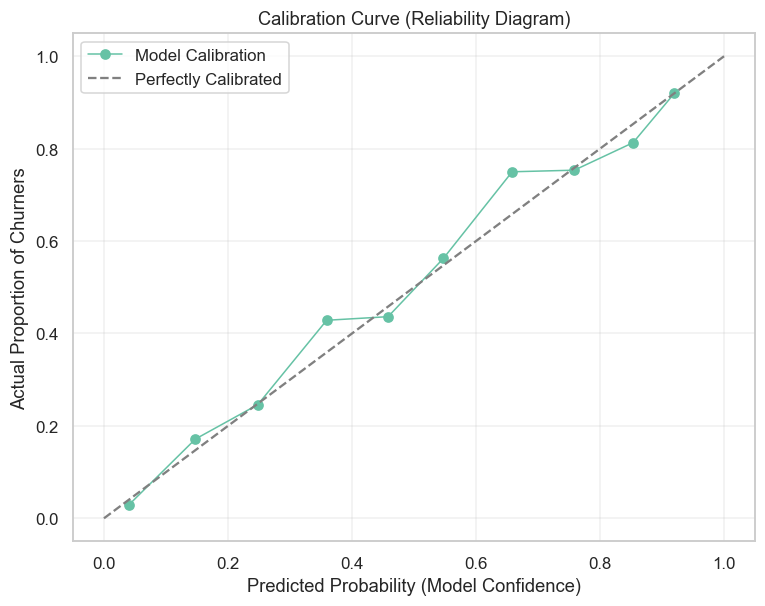

In [53]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
#help from gemini
# 1. Calculate calibration binned counts
# y_test: actual outcomes, y_scores: predicted probabilities
prob_true, prob_pred = calibration_curve(y_test, y_scores, n_bins=10)

# 2. Plotting
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Model Calibration')

# The "Perfect" Line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Predicted Probability (Model Confidence)')
plt.ylabel('Actual Proportion of Churners')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Analysis: Logistic model is best according to ROC curve and PR curve when comparing the different models. Calculating different thresholds changes our recall (more important than accuracy here). If retension action is cheap set threshold at 0.11, if retension action is expensive 0.3 threshold. 

Higher recall will miss less true churners, but as recall rises, precision drops. This means that at 0.15 threshold, we hit 96% of potential churners, but about 38% of them were false churners so we either annoy these customers or give away free promos to those who weren't going to churn. On the flip side if we raise the threshold we start to miss out on true churners. 

The optimal threshold for maximum recall is 0.11 where the calibration shows it is ready for deployment. However if our retension action cost too much money we can scale back to the optimal balance of 0.3 treshold with optimal F1-score. If our retension action is very expensive we can increase our threshold more, but we see a large drop when increasing anymore than 0.5. 

--- 
## STEP 8 — Decision Engine: Main Mechanism

This engine serves as a decision layer that translates churn prediction model outputs into actionable business responses, providing prioritized and personalized retention strategies for each at-risk customer.

Retention incentives should account for both the **likelihood of churn** and the **expected revenue loss** from that churn. The engine is built on the following mechanism:

**1. Identify At-Risk Customers**
Extract customers with a churn probability ≥ 0.5 based on the logistic regression model.

**2. Estimate Expected Loss per Customer**
Using four customer attributes available in the dataset — Gender, Senior Citizen, Partner, and Dependents — customers are segmented into 16 groups.

- Average tenure differs significantly across groups, enabling group-based tenure estimation.
  *(Two groups with n=2 and n=4 are replaced with the overall no-churn average tenure.)*
  *(ANOVA: F-statistic = 65.58, p ≈ 0.000 — group differences are statistically significant.)*
- Customers whose current tenure already exceeds their group average (14.9% of at-risk customers, n=425) are assigned a remaining tenure of min(12 months, 72 − current tenure), where 72 months is the maximum contract period in this dataset.
- **Expected Loss** = Remaining Tenure × Monthly Charges × Assumed Margin Rate (20%) × Churn Risk Uncertainty Discount (50%)

**3. Identify Optimal Retention Actions**
Using the logistic regression model, simulate the effect of each available service intervention on churn probability for the individual customer. Rank the Top 5 single actions by churn probability reduction:
- Online Security, Online Backup, Device Protection, Tech Support *(add service)*
- Contract change *(Month-to-month → One year / Two year)*
- Payment method change *(Electronic check → other methods)*

**4. Recommend Action by Grade**
Combine churn probability level and expected loss relative to the at-risk group median to assign a response grade:

| Grade | Churn Probability | Expected Loss | Recommended Action |
|---|---|---|---|
| A | ≥ 0.7 | ≥ Median | Immediate call + Top 2 action combo + Active financial support |
| B | ≥ 0.7 | < Median | Phone call + Top 1 action + Minor financial support |
| C | 0.5 – 0.7 | ≥ Median | Email + Top 1 action + Minor financial support |
| D | 0.5 – 0.7 | < Median | Email notification only |



**A note on recommended actions:**
Although the engine identifies the most effective retention action for each individual customer, contract type change consistently emerged as the dominant recommendation across most cases — aligned with the Cox proportional hazards model, which identified month-to-month contract as the single strongest predictor of churn risk.

### data load

In [54]:
import pandas as pd
import numpy as np
import random
import joblib
import sys
from scipy.stats import f_oneway



feature_columns = X_train.columns.tolist()
no_churn_df     = df_clean[df_clean['Churn'] == 0].copy()

print("load complete")

load complete


In [55]:
### Customer Segmentation by Demographic Profile and Validating Group-Based Tenure Estimation via ANOVA

In [56]:
group_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']

no_churn_df = df_clean[df_clean['Churn'] == 0].copy()

group_counts = (
    no_churn_df
    .groupby(group_cols)
    .agg(
        count=('Tenure Months', 'count'),
        avg_tenure=('Tenure Months', 'mean')
    )
    .reset_index()
    .sort_values('avg_tenure', ascending=True)
)

print(group_counts)

    Gender  Senior Citizen  Partner  Dependents  count  avg_tenure
1        0               0        0           1     98       24.03
9        1               0        0           1    148       26.24
8        1               0        0           0    983       27.50
13       1               1        0           1      4       28.00
0        0               0        0           0    921       28.21
5        0               1        0           1      2       31.50
4        0               1        0           0    159       34.36
12       1               1        0           0    126       34.47
3        0               0        1           1    610       42.60
11       1               0        1           1    604       43.01
14       1               1        1           0    181       46.04
7        0               1        1           1     28       46.07
2        0               0        1           0    592       47.86
10       1               0        1           0    552       4

In [57]:
group_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']

# Extract tenure values per group (exclude groups with fewer than 5 samples)
groups = []
for name, group in no_churn_df.groupby(group_cols)['Tenure Months']:
    if len(group) >= 5:
        groups.append(group.values)

# One-way ANOVA: test whether average tenure differs significantly across groups
stat, p_value = f_oneway(*groups)

print(f"ANOVA F-statistic : {stat:.4f}")
print(f"p-value           : {p_value:.6f}")
print(f"Statistical significance : {'Significant (p < 0.05)' if p_value < 0.05 else 'Not significant'}")

ANOVA F-statistic : 65.5823
p-value           : 0.000000
Statistical significance : Significant (p < 0.05)


### Main Decision Engine

In [58]:
# 1. Configuration
THRESHOLD         = 0.5
MIN_GROUP_COUNT   = 20
MARGIN_RATE       = 0.2
TENURE_ASSUMPTION = 0.5

# 2. Action Definitions
ACTION_GROUPS = {
    "online_security":   {"Add Online Security":     {"Online Security_Yes": 1, "Online Security_No": 0}},
    "online_backup":     {"Add Online Backup":       {"Online Backup_Yes": 1, "Online Backup_No": 0}},
    "device_protection": {"Add Device Protection":   {"Device Protection_Yes": 1, "Device Protection_No": 0}},
    "tech_support":      {"Add Tech Support":        {"Tech Support_Yes": 1, "Tech Support_No": 0}},
    "contract": {
        "Switch to 1-Year Contract": {"Contract_Month-to-month": 0, "Contract_One year": 1},
        "Switch to 2-Year Contract": {"Contract_Month-to-month": 0, "Contract_Two year": 1},
    },
    "payment": {
        "Switch to Mailed Check":        {"Payment Method_Electronic check": 0, "Payment Method_Mailed check": 1},
        "Switch to Bank Transfer":       {"Payment Method_Electronic check": 0, "Payment Method_Bank transfer (automatic)": 1},
        "Switch to Credit Card":         {"Payment Method_Electronic check": 0, "Payment Method_Credit card (automatic)": 1},
    }
}

ACTIONS = {}
ACTION_TO_GROUP = {}
for group_name, actions in ACTION_GROUPS.items():
    for action_name, changes in actions.items():
        ACTIONS[action_name] = changes
        ACTION_TO_GROUP[action_name] = group_name

# 3. Group Average Tenure Table (pre-computed, ranked)
group_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']

group_avg = (
    no_churn_df
    .groupby(group_cols)['Tenure Months']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_tenure', 'count': 'n'})
)
global_avg = no_churn_df['Tenure Months'].mean()

# rank groups by avg_tenure descending (rank 1 = highest)
group_avg_sorted = group_avg.sort_values('avg_tenure', ascending=False).reset_index(drop=True)
group_avg_sorted['rank'] = group_avg_sorted.index + 1
total_groups = len(group_avg_sorted)  # 16

def get_group_info(customer_row):
    """Return avg_tenure and rank label for the customer's demographic group."""
    mask = pd.Series([True] * len(group_avg_sorted), index=group_avg_sorted.index)
    for col in group_cols:
        mask &= (group_avg_sorted[col] == customer_row[col])
    matched = group_avg_sorted[mask]

    if not matched.empty and matched.iloc[0]['n'] >= MIN_GROUP_COUNT:
        avg_t  = matched.iloc[0]['avg_tenure']
        rank   = int(matched.iloc[0]['rank'])
        source = f"Group avg_tenure rank {rank} of {total_groups}"
    else:
        avg_t  = global_avg
        source = "Overall no-churn average used (group too small)"
    return avg_t, source

# 4. Pre-compute Expected Loss Median (at-risk customers only)
all_probs    = lr_model.predict_proba(df_clean[feature_columns])[:, 1]
high_risk_df = df_clean[all_probs > THRESHOLD].copy()

losses = []
for idx, row in high_risk_df.iterrows():
    avg_t, _ = get_group_info(row)
    remaining = max(avg_t - row['Tenure Months'], 0)
    losses.append(remaining * row['Monthly Charges'] * MARGIN_RATE)

loss_median = pd.Series(losses).median()
print(f"At-risk customers : {len(high_risk_df)}")
print(f"Expected loss median : ${loss_median:.2f}")

# 5. Customer Profile Display (4 items per line)
def decode_customer_profile(customer_row):
    def find_category(prefix):
        cols = [c for c in customer_row.index if c.startswith(prefix) and customer_row[c] == 1]
        return cols[0].replace(prefix, "") if cols else "Unknown"

    service_cols = ["Online Security", "Online Backup", "Device Protection",
                    "Tech Support", "Streaming TV", "Streaming Movies"]
    services = [s for s in service_cols if customer_row.get(f"{s}_Yes", 0) == 1]

    items = [
        ("Tenure",     f"{int(customer_row.get('Tenure Months', 0))} months"),
        ("Monthly",    f"${customer_row.get('Monthly Charges', 0):.2f}"),
        ("Gender",     "Male" if customer_row.get("Gender", 0) == 1 else "Female"),
        ("Senior",     "Yes"  if customer_row.get("Senior Citizen", 0) == 1 else "No"),
        ("Partner",    "Yes"  if customer_row.get("Partner", 0) == 1 else "No"),
        ("Dependents", "Yes"  if customer_row.get("Dependents", 0) == 1 else "No"),
        ("Internet",   find_category("Internet Service_")),
        ("Contract",   find_category("Contract_")),
        ("Payment",    find_category("Payment Method_")),
        ("Services",   ", ".join(services) if services else "None"),
    ]

    lines = []
    for i in range(0, len(items), 4):
        chunk = items[i:i+4]
        lines.append("  " + "  |  ".join(f"{k}: {v}" for k, v in chunk))
    return lines

# 6. Expected Loss Estimation
def estimate_expected_loss(customer_row):
    avg_t, source  = get_group_info(customer_row)
    current_tenure = customer_row['Tenure Months']

    if current_tenure > avg_t:
        # already exceeded group avg: cap remaining at min(12, 72 - current)
        remaining = min(12, max(72 - current_tenure, 0))
        source    = source + " / exceeds group avg → remaining = min(12, 72 - tenure)"
    else:
        remaining = avg_t - current_tenure

    expected_loss     = remaining * customer_row['Monthly Charges'] * MARGIN_RATE
    expected_loss_adj = expected_loss * TENURE_ASSUMPTION

    return {
        "expected_loss":     round(expected_loss, 2),
        "expected_loss_adj": round(expected_loss_adj, 2),
        "avg_tenure":        round(avg_t, 2),
        "remaining_tenure":  round(remaining, 2),
        "source":            source
    }

# 7. Response Grade Classification 
GRADE_GUIDE = (
    "Grade criteria: Churn prob >= 0.7 = High / 0.5-0.7 = Mid  |  Expected loss >= median = Upper / < median = Lower\n"
    "  A (High + Upper): Immediate call + Top-2 combo + Active financial support\n"
    "  B (High + Lower): Phone call + Top-1 action + Minor financial support\n"
    "  C (Mid  + Upper): Email + Top-1 action + Minor financial support\n"
    "  D (Mid  + Lower): Email notification only"
)

def classify_response(churn_prob, expected_loss):
    prob_grade = "High" if churn_prob >= 0.7 else "Mid"
    loss_grade = "Upper" if expected_loss >= loss_median else "Lower"
    grade_map  = {
        ("High", "Upper"): {"grade": "A", "action": "Top2 Combo",   "incentive": "Active financial support",  "desc": "Immediate call + Top-2 combo + Active financial support"},
        ("High", "Lower"): {"grade": "B", "action": "Top1 Action",  "incentive": "Minor financial support",   "desc": "Phone call + Top-1 action + Minor financial support"},
        ("Mid",  "Upper"): {"grade": "C", "action": "Top1 Action",  "incentive": "Minor financial support",   "desc": "Email + Top-1 action + Minor financial support"},
        ("Mid",  "Lower"): {"grade": "D", "action": "Email Only",   "incentive": "None",                      "desc": "Email notification only"},
    }
    return grade_map[(prob_grade, loss_grade)]

# 8. Action Simulation 
def simulate_single_actions(customer_row, churn_prob):
    results = []
    for action_name, changes in ACTIONS.items():
        modified = customer_row[feature_columns].copy()
        if not all(f in modified.index for f in changes):
            continue
        if all(modified.get(f, None) == v for f, v in changes.items()):
            continue
        for f, v in changes.items():
            modified[f] = v
        new_prob = lr_model.predict_proba(
            pd.DataFrame([modified], columns=feature_columns)
        )[0][1]
        results.append({
            "Action":           action_name,
            "Group":            ACTION_TO_GROUP[action_name],
            "Churn Prob":       round(churn_prob, 3),
            "Prob After":       round(new_prob, 3),
            "Reduction":        round(churn_prob - new_prob, 3),
            "Below 0.5":        "✓" if new_prob < THRESHOLD else "✗"
        })
    return pd.DataFrame(results).sort_values("Reduction", ascending=False)

def simulate_top2_combo(customer_row, action_df, churn_prob):
    if len(action_df) < 2:
        return None
    top1   = action_df.iloc[0]
    others = action_df[action_df["Group"] != top1["Group"]]
    if others.empty:
        return None
    top2     = others.iloc[0]
    modified = customer_row[feature_columns].copy()
    for action_name in [top1["Action"], top2["Action"]]:
        for f, v in ACTIONS[action_name].items():
            modified[f] = v
    new_prob = lr_model.predict_proba(
        pd.DataFrame([modified], columns=feature_columns)
    )[0][1]
    return {
        "Action":    f"{top1['Action']}  +  {top2['Action']}",
        "Churn Prob": round(churn_prob, 3),
        "Prob After": round(new_prob, 3),
        "Reduction":  round(churn_prob - new_prob, 3),
        "Below 0.5":  "✓" if new_prob < THRESHOLD else "✗"
    }

# 9. Decision Engine 
def decision_engine(customer_row, print_grade_guide=False):
    churn_prob = lr_model.predict_proba(
        pd.DataFrame([customer_row[feature_columns]], columns=feature_columns)
    )[0][1]

    if churn_prob < THRESHOLD:
        print(f"Churn prob {churn_prob:.3f} — below threshold ({THRESHOLD}). No action needed.")
        return None

    print("=" * 65)
    if print_grade_guide:
        print(GRADE_GUIDE)
        print("-" * 65)

    print(f"Churn Probability: {churn_prob:.3f}")

    profile_lines = decode_customer_profile(customer_row)
    print(f"\n[ Customer Profile ]")
    for line in profile_lines:
        print(line)

    loss_info  = estimate_expected_loss(customer_row)
    loss_grade = "Upper" if loss_info["expected_loss"] >= loss_median else "Lower"
    print(f"\n[ Expected Loss Estimate ]")
    print(f"  Avg Tenure (group)    : {loss_info['avg_tenure']} months  ({loss_info['source']})")
    print(f"  Remaining Tenure      : {loss_info['remaining_tenure']} months")
    print(f"  Expected Loss (20%)   : ${loss_info['expected_loss']}  ({loss_grade} / median ${loss_median:.2f})")
    print(f"  Adj. Loss (50% disc.) : ${loss_info['expected_loss_adj']}")

    grade_info = classify_response(churn_prob, loss_info["expected_loss"])
    print(f"\n[ Response Grade: {grade_info['grade']} ]  {grade_info['desc']}")
    print(f"  Incentive: {grade_info['incentive']}")

    action_df = simulate_single_actions(customer_row, churn_prob)

    if grade_info["action"] == "Email Only":
        print(f"\n[ Recommended Action ] Email notification only")

    else:
        best_single     = action_df.iloc[0] if not action_df.empty else None
        single_achieves = best_single is not None and best_single["Prob After"] < THRESHOLD

        print(f"\n[ Recommended Actions ]")

        if single_achieves:
            top5 = action_df.head(5).reset_index(drop=True)
            top5.index += 1
            print(top5[["Action", "Churn Prob", "Prob After", "Reduction", "Below 0.5"]].to_string())

        else:
            combo       = simulate_top2_combo(customer_row, action_df, churn_prob)
            single_top4 = action_df.head(4)
            rows = []
            if combo:
                rows.append({
                    "Action":    combo["Action"],
                    "Churn Prob": combo["Churn Prob"],
                    "Prob After": combo["Prob After"],
                    "Reduction":  combo["Reduction"],
                    "Below 0.5":  combo["Below 0.5"]
                })
            for _, row in single_top4.iterrows():
                rows.append({
                    "Action":    row["Action"],
                    "Churn Prob": row["Churn Prob"],
                    "Prob After": row["Prob After"],
                    "Reduction":  row["Reduction"],
                    "Below 0.5":  row["Below 0.5"]
                })
            result_df = pd.DataFrame(rows).reset_index(drop=True)
            result_df.index += 1
            print(result_df[["Action", "Churn Prob", "Prob After", "Reduction", "Below 0.5"]].to_string())

    print("=" * 65)

    return {
        "churn_prob":        churn_prob,
        "expected_loss":     loss_info["expected_loss"],
        "expected_loss_adj": loss_info["expected_loss_adj"],
        "grade":             grade_info["grade"],
        "grade_info":        grade_info,
        "action_df":         action_df
    }

At-risk customers : 2857
Expected loss median : $268.96


## Decision Engine Test Run
### Simulating Retention Responses for 5 Randomly Sampled At-Risk Customers

In [59]:
#  Batch Execution
def run_batch(n, seed=42):
    all_probs     = lr_model.predict_proba(df_clean[feature_columns])[:, 1]
    high_risk_idx = df_clean.index[all_probs > THRESHOLD].tolist()

    print(f"At-risk customers (threshold > {THRESHOLD}): {len(high_risk_idx)}  |  Running: {n} samples")
    print("=" * 65)
    print(GRADE_GUIDE)
    print("=" * 65)

    random.seed(seed)
    sampled = random.sample(high_risk_idx, min(n, len(high_risk_idx)))

    records = []
    for i, idx in enumerate(sampled):
        print(f"\n{'━'*65}")
        print(f"[{i+1}/{n}] Customer index: {idx}")
        result = decision_engine(df_clean.loc[idx], print_grade_guide=False)
        if result is None:
            continue

        grade = result["grade"]
        if grade == "D" or result["action_df"].empty:
            action_summary = "Email Only"
            prob_after     = "-"
            reduction      = "-"
        else:
            top1           = result["action_df"].iloc[0]
            action_summary = top1["Action"]
            prob_after     = top1["Prob After"]
            reduction      = top1["Reduction"]

        records.append({
            "Index":          idx,
            "Churn Prob":     round(result["churn_prob"], 3),
            "Exp. Loss ($)":  result["expected_loss"],
            "Adj. Loss ($)":  result["expected_loss_adj"],
            "Grade":          grade,
            "Incentive":      result["grade_info"]["incentive"],
            "Top Action":     action_summary,
            "Prob After":     prob_after,
            "Reduction":      reduction,
        })

    print(f"\n{'='*65}")
    print(f"[ Batch Summary — {n} customers ]")
    summary_df = pd.DataFrame(records).sort_values("Exp. Loss ($)", ascending=False)
    print(summary_df.to_string(index=False))
    return summary_df

with open("decision_engine_output.txt", "w", encoding="utf-8") as f:
    sys.stdout = f
    summary = run_batch(n=5)
    sys.stdout = sys.__stdout__

print("Saved successfully → decision_engine_output.txt")

UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 19: character maps to <undefined>

## SHAP explainability — Logistic regression

[SHAP](https://shap.readthedocs.io/) values show how each feature pushes the model output away from the **dataset average**. For `sklearn` logistic regression, `LinearExplainer` uses the **linear part (log-odds)** before the sigmoid; higher log-odds still means higher churn risk.

**Plot 1 —** average strength of each feature across many test rows. **Plot 2 —** each dot is one customer for that feature; horizontal position is impact, color is whether their feature value is low or high. **Plot 3 —** one at-risk customer: baseline → each contribution → total log-odds.

`pip install shap plotly` if these packages are missing.

In [ ]:
import numpy as np
import pandas as pd
import shap
import plotly.express as px
import plotly.graph_objects as go

# Linear SHAP for sklearn LogisticRegression (explains log-odds / margin before sigmoid)
explainer = shap.LinearExplainer(lr_model, X_train)

X_shap = X_test if len(X_test) <= 2000 else X_test.sample(2000, random_state=42)
sv = explainer.shap_values(X_shap)
ev = explainer.expected_value

if isinstance(sv, list):
    shap_vals = np.asarray(sv[1])
else:
    shap_vals = np.asarray(sv)

ev_arr = np.asarray(ev).ravel()
expected_val = float(ev_arr[1] if ev_arr.size >= 2 else ev_arr[0])

feature_names = list(X_shap.columns)
n, m = shap_vals.shape
mean_abs = np.abs(shap_vals).mean(axis=0)

# --- Plot 1: Global mean |SHAP| (horizontal bar) ---
top_n = min(25, m)
order_bar = np.argsort(mean_abs)[::-1][:top_n][::-1]
fig1 = go.Figure(
    go.Bar(
        x=mean_abs[order_bar],
        y=[feature_names[i] for i in order_bar],
        orientation="h",
        marker_color="steelblue",
    )
)
fig1.update_layout(
    title="<b>1. Global feature impact</b><br><sup>Mean |SHAP| on held-out rows (larger = stronger average influence)</sup>",
    xaxis_title="Mean |SHAP value|",
    yaxis_title="",
    template="plotly_white",
    height=max(420, top_n * 22),
    margin=dict(l=180, t=90, r=30),
)
fig1.show()

# --- Plot 2: Beeswarm-style (SHAP summary with feature value coloring) ---
rng = np.random.default_rng(42)
sample_idx = rng.choice(n, size=min(500, n), replace=False)
top_k = 14
feat_order = np.argsort(mean_abs)[::-1][:top_k]
rows = []
for j in feat_order:
    fname = feature_names[j]
    col_vals = X_shap[fname].iloc[sample_idx].to_numpy(dtype=float)
    lo, hi = float(np.min(col_vals)), float(np.max(col_vals))
    span = hi - lo if hi > lo else 1.0
    w = (col_vals - lo) / span
    for ii, i in enumerate(sample_idx):
        rows.append({"SHAP": shap_vals[i, j], "Feature": fname, "val_norm": w[ii]})
bee_df = pd.DataFrame(rows)
feat_cat = [feature_names[j] for j in feat_order]
bee_df["Feature"] = pd.Categorical(bee_df["Feature"], categories=feat_cat[::-1], ordered=True)

fig2 = px.scatter(
    bee_df,
    x="SHAP",
    y="Feature",
    color="val_norm",
    color_continuous_scale="RdBu_r",
    range_color=(0, 1),
    opacity=0.65,
)
fig2.update_traces(marker=dict(size=6, line=dict(width=0)))
fig2.update_layout(
    title="<b>2. How features move individual customers</b><br><sup>Each dot = one customer; color = feature value (blue = low, red = high) within that feature</sup>",
    xaxis_title="SHAP value (impact on log-odds)",
    yaxis_title="",
    template="plotly_white",
    height=520,
    margin=dict(l=160, t=90, r=20),
    coloraxis_colorbar=dict(title="Feature<br>value<br>(norm.)"),
)
fig2.show()

# --- Plot 3: Waterfall — one highest predicted-risk customer ---
probs = lr_model.predict_proba(X_shap)[:, 1]
idx_one = int(np.argmax(probs))
sv_row = shap_vals[idx_one]
pred_margin = float(lr_model.decision_function(X_shap.iloc[[idx_one]])[0])
p_churn = float(probs[idx_one])

K = 15
ord_feat = np.argsort(np.abs(sv_row))[::-1][:K]
rest = float(sv_row.sum() - sv_row[ord_feat].sum())

x_list = ["Expected<br>(avg log-odds)"]
measure_list = ["absolute"]
y_list = [expected_val]
for j in ord_feat:
    x_list.append(feature_names[j])
    measure_list.append("relative")
    y_list.append(float(sv_row[j]))
if abs(rest) > 1e-9:
    x_list.append("Other features")
    measure_list.append("relative")
    y_list.append(rest)
x_list.append("Predicted<br>log-odds")
measure_list.append("total")
y_list.append(0)

fig3 = go.Figure(
    go.Waterfall(
        name="SHAP",
        orientation="v",
        measure=measure_list,
        x=x_list,
        y=y_list,
        textposition="outside",
        connector={"line": {"color": "#888"}},
    )
)
fig3.update_layout(
    title=(
        f"<b>3. One customer: baseline → prediction</b><br>"
        f"<sup>Highest P(churn) in this sample = {p_churn:.3f}; SHAP sum matches margin: "
        f"{np.isclose(expected_val + sv_row.sum(), pred_margin, rtol=1e-4, atol=1e-4)}</sup>"
    ),
    yaxis_title="Log-odds (margin)",
    template="plotly_white",
    height=520,
    margin=dict(b=120, t=90, l=50, r=30),
    showlegend=False,
)
fig3.show()

In [ ]:
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import shap
from scipy.special import expit

display(
    Markdown(
        r"""
### Logistic regression + SHAP — what this means **for one customer**

**1. What the model is doing (logistic regression)**  
The model first forms a **score** (log-odds): \(s = \beta_0 + \sum_i \beta_i x_i\), using your trained coefficients \(\beta\) and this customer’s feature values \(x\).  
Then it converts that to a probability: **P(churn) = σ(s)** where σ is the logistic curve. So **higher \(s\)** ⇒ higher churn risk. The \(\beta_i\) are **global** slopes: they describe how the score moves with each feature *in general*, not yet “why this person.”

**2. What SHAP adds (local explainability)**  
**SHAP** (here `LinearExplainer`, exact for logistic regression) splits this customer’s score into a **baseline** plus **per-feature contributions** \(\phi_i\) that **sum to \(s\)** (up to the explainer’s baseline convention):  
**baseline** ≈ average log-odds over a **reference population** (we use `X_train`) + **\(\sum_i \phi_i\)** = this customer’s **\(s\)**.  
Each \(\phi_i\) answers: *how much did feature \(i\) push this person’s log-odds **above or below** that average?* That is the **local** “why” on top of the global \(\beta_i\).

**3. How to read the three figures below**  
- **Gauge:** your customer’s **P(churn) = σ(s)** and how it compares to the **average churn rate** in the data (a simple benchmark, not the same as the SHAP baseline).  
- **Red / green bars:** \(\phi_i\) on **log-odds** — red pushes risk **up** vs a typical profile, green **down** (relative to the training-based baseline).  
- **Waterfall:** the same \(\phi_i\) as a path from **baseline log-odds** → **final \(s\)**; applying σ to the end recovers **P(churn)**.

**4. Pick the customer**  
Set `CUSTOMER_INDEX` to a row label from `df_clean`, or `None` for a random row (`RANDOM_SEED` fixes reproducibility).
"""
    )
)

# --- Pick one row: label in df_clean.index, or None = random ---
CUSTOMER_INDEX = None
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)
if CUSTOMER_INDEX is None:
    idx = rng.choice(df_clean.index.to_numpy(), size=1).item()
else:
    idx = CUSTOMER_INDEX
    if idx not in df_clean.index:
        raise KeyError(f"CUSTOMER_INDEX={idx!r} not found in df_clean.index")

row = df_clean.loc[idx]
X_one = pd.DataFrame([row[feature_columns].to_numpy()], columns=feature_columns)

proba_churn = float(lr_model.predict_proba(X_one)[0, 1])
pred_label = int(lr_model.predict(X_one)[0])
margin = float(lr_model.decision_function(X_one)[0])
avg_churn = float(df_clean["Churn"].mean())

actual = int(row["Churn"]) if "Churn" in row.index and pd.notna(row["Churn"]) else None

explainer = shap.LinearExplainer(lr_model, X_train)
sv = explainer.shap_values(X_one)
ev = explainer.expected_value
if isinstance(sv, list):
    sv_row = np.asarray(sv[1], dtype=float).ravel()
else:
    sv_row = np.asarray(sv, dtype=float).ravel()

ev_arr = np.asarray(ev, dtype=float).ravel()
expected_val = float(ev_arr[1] if ev_arr.size >= 2 else ev_arr[0])

fnames = list(feature_columns)
K = min(20, len(fnames))
top_by_abs = np.argsort(np.abs(sv_row))[::-1][:K]
order = top_by_abs[::-1]
colors = ["#c0392b" if sv_row[j] >= 0 else "#1e8449" for j in order]

# --- 1) Gauge: P(churn) ---
fig_g = go.Figure(
    go.Indicator(
        mode="gauge+number+delta",
        value=round(proba_churn * 100, 2),
        number={"suffix": " %", "font": {"size": 40}},
        delta={"reference": round(avg_churn * 100, 2), "suffix": " %"},
        gauge={
            "axis": {"range": [0, 100]},
            "bar": {"color": "#922b21"},
            "steps": [
                {"range": [0, 25], "color": "#eafaf1"},
                {"range": [25, 50], "color": "#fff4e6"},
                {"range": [50, 100], "color": "#fdecea"},
            ],
            "threshold": {
                "line": {"color": "#2c3e50", "width": 2},
                "thickness": 0.75,
                "value": 50,
            },
        },
        title={"text": f"<b>Predicted churn risk</b><br><sup>df_clean index = {idx}</sup>"},
    )
)
fig_g.update_layout(height=340, template="plotly_white", margin=dict(t=100, b=40))
fig_g.show()

print(f"Index: {idx}  |  P(churn) = {proba_churn:.4f}  |  predicted class = {pred_label}")
if actual is not None:
    print(f"Actual Churn = {actual}  (1 = churned)")
print(f"Log-odds s = {margin:.4f}   (σ(s) = {expit(margin):.4f})")
print(f"SHAP baseline E[s] = {expected_val:.4f}  |  sum(SHAP) + baseline = {expected_val + sv_row.sum():.4f}")

# --- 2) SHAP bar: drivers vs average ---
fig_bar = go.Figure(
    go.Bar(
        x=[float(sv_row[j]) for j in order],
        y=[fnames[j] for j in order],
        orientation="h",
        marker_color=colors,
    )
)
fig_bar.add_vline(x=0, line_width=1, line_dash="dot", line_color="black")
fig_bar.update_layout(
    title="<b>Why this number?</b> SHAP φᵢ on <b>log-odds</b> "
          "(<span style='color:#c0392b'>red</span> = higher churn vs avg, "
          "<span style='color:#1e8449'>green</span> = lower)",
    xaxis_title="SHAP contribution φᵢ (Δ log-odds vs training baseline)",
    yaxis_title="",
    template="plotly_white",
    height=140 + 26 * K,
    margin=dict(l=220, t=90, r=40, b=50),
)
fig_bar.show()

# --- 3) Waterfall: baseline → contributions → final margin ---
top_m = 14
ord_feat = np.argsort(np.abs(sv_row))[::-1][:top_m]
rest = float(sv_row.sum() - sv_row[ord_feat].sum())

x_list = ["Baseline<br>E[log-odds]"]
measure_list = ["absolute"]
y_list = [expected_val]
for j in ord_feat:
    x_list.append(fnames[j])
    measure_list.append("relative")
    y_list.append(float(sv_row[j]))
if abs(rest) > 1e-9:
    x_list.append("Other features")
    measure_list.append("relative")
    y_list.append(rest)
x_list.append("Final<br>log-odds s")
measure_list.append("total")
y_list.append(0)

fig_w = go.Figure(
    go.Waterfall(
        orientation="v",
        measure=measure_list,
        x=x_list,
        y=y_list,
        textposition="outside",
        connector={"line": {"color": "#888"}},
    )
)
fig_w.update_layout(
    title=(
        "<b>From average score to this customer’s score</b><br>"
        f"<sup>σ(E[s] + Σφ) = σ({margin:.3f}) = {proba_churn:.3f} = P(churn)</sup>"
    ),
    yaxis_title="Log-odds",
    template="plotly_white",
    height=500,
    margin=dict(b=140, t=100, l=50, r=30),
    showlegend=False,
)
fig_w.show()
